<a href="https://colab.research.google.com/github/Leeraaa/Deep-Learning/blob/main/DeepLearningProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset

The CROHME23 offline dataset is a collection of static images of handwritten mathematical expressions obtained by scanning or photographing paper records. It includes a wide variety of images that capture differences in quality, writing styles, and the structural complexity of formulas. This dataset provides realistic conditions for developing and testing algorithms aimed at converting handwritten input into LaTeX code.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/Deep Learning/CROHME23.zip'

In [ ]:
import zipfile

with zipfile.ZipFile(file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/crohme_data')

In [ ]:
import os

train_label_path = '/content/crohme_data/TC11_CROHME23/SymLG/train/OffHME/'
test_label_path = '/content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/'
test_img_path = '/content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/'
train_img_path = '/content/crohme_data/TC11_CROHME23/IMG/train/OffHME/'

# Checking the training set
train_images = os.listdir(train_img_path)
train_labels = os.listdir(train_label_path)
print(f"Found training images: {len(train_images)}")
print(f"Found training labels: {len(train_labels)}")

# Checking the test set
test_images = os.listdir(test_img_path)
test_labels = os.listdir(test_label_path)
print(f"Found test images: {len(test_images)}")
print(f"Found test labels: {len(test_labels)}")

Found training images: 10000
Found training labels: 10000
Found test images: 2354
Found test labels: 2299


# Filtering data

Here, we perform data filtering, validation, and cleaning as part of dataset preparation.

## Filtering test data

In [ ]:
def filter_test_data(image_path, label_path):
    image_files = [f for f in os.listdir(image_path) if f.endswith(('png', 'jpg', 'jpeg'))]
    label_files = [f for f in os.listdir(label_path) if f.endswith('.lg')]
    matched_data = []

    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        label_file = f"{base_name}.lg"  # Corresponding label file name

        if label_file in label_files:
            matched_data.append({
                'image': os.path.join(image_path, img_file),
                'label': os.path.join(label_path, label_file)
            })
        else:
            print(f"Skipped image: {img_file} (label missing)")

    return matched_data

# Filter test data
filtered_test_data = filter_test_data(test_img_path, test_label_path)
print(f"Remaining test data: {len(filtered_test_data)} images and labels")

Skipped image: form_336_E2681.png (label missing)
Skipped image: form_5_665_E3325.png (label missing)
Skipped image: form_5_f_267_E1334.png (label missing)
Skipped image: form_319_E2548.png (label missing)
Skipped image: form_5_734_E3668.png (label missing)
Skipped image: form_5_f_304_E1520.png (label missing)
Skipped image: form_5_f_750_E3746.png (label missing)
Skipped image: form_5_723_E3611.png (label missing)
Skipped image: form_5_310_E1546.png (label missing)
Skipped image: form_5_f_217_E1085.png (label missing)
Skipped image: form_5_300_E1498.png (label missing)
Skipped image: form_5_f_293_E1463.png (label missing)
Skipped image: form_5_280_E1398.png (label missing)
Skipped image: form_5_f_293_E1462.png (label missing)
Skipped image: form_096_E767.png (label missing)
Skipped image: form_5_294_E1470.png (label missing)
Skipped image: form_091_E724.png (label missing)
Skipped image: form_237_E1892.png (label missing)
Skipped image: form_5_f_304_E1519.png (label missing)
Skipped im

## Function to print all data from a file

In [ ]:
def print_file_contents(lg_file):

    try:
        with open(lg_file, 'r') as file:
            lines = file.readlines()
            print(f"Contents of file {lg_file}:")
            for line in lines:
                print(line.strip())
            print("-" * 40)
    except Exception as e:
        print(f"Error reading file {lg_file}: {e}")

In [ ]:
# Print an example from the training data
train_files = [f for f in os.listdir(train_label_path) if f.endswith('.lg')]
if train_files:
    first_train_file = os.path.join(train_label_path, train_files[0])
    print("Example of a training file:")
    print_file_contents(first_train_file)

Example of a training file:
Contents of file /content/crohme_data/TC11_CROHME23/SymLG/train/OffHME/05239.lg:
# IUD, Formula00_12896_tru_norm
# Objects(15):
O, (_2, (, 1.0, O
O, B_3, B, 1.0, OR
O, y_4, y, 1.0, ORR
O, +_5, +, 1.0, ORRR
O, \beta_6, \beta, 1.0, ORRRR
O, +_7, +, 1.0, ORRRRR
O, 1_8, 1, 1.0, ORRRRRR
O, )_10, ), 1.0, ORRRRRRR
O, n_11, n, 1.0, ORRRRRRRSup
O, \leq_12, \leq, 1.0, ORRRRRRRR
O, B_14, B, 1.0, ORRRRRRRRR
O, n_15, n, 1.0, ORRRRRRRRRSup
O, x_16, x, 1.0, ORRRRRRRRRR
O, +_17, +, 1.0, ORRRRRRRRRRR
O, \alpha_18, \alpha, 1.0, ORRRRRRRRRRRR


# Relations from SRT:
R, (_2, B_3, Right, 1.0
R, )_10, \leq_12, Right, 1.0
R, )_10, n_11, Sup, 1.0
R, +_17, \alpha_18, Right, 1.0
R, +_5, \beta_6, Right, 1.0
R, +_7, 1_8, Right, 1.0
R, 1_8, )_10, Right, 1.0
R, B_14, n_15, Sup, 1.0
R, B_14, x_16, Right, 1.0
R, B_3, y_4, Right, 1.0
R, \beta_6, +_7, Right, 1.0
R, \leq_12, B_14, Right, 1.0
R, x_16, +_17, Right, 1.0
R, y_4, +_5, Right, 1.0

# Bounding boxes
BB, (_2, 3.4483, 66.4483, 40.5172,

In [ ]:
# Print an example from the test data
test_files = [f for f in os.listdir(test_label_path) if f.endswith('.lg')]
if test_files:
    first_test_file = os.path.join(test_label_path, test_files[0])
    print("Example of a test file:")
    print_file_contents(first_test_file)

Example of a test file:
Contents of file /content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_210_E1679.lg:
# IUD, form_210_Eq7
# Objects(6):
O, r_1, r, 1.0, ORR
O, 1_1, 1, 1.0, ORRRR
O, -_1, -, 1.0, ORRR
O, log_1, \log, 1.0, O
O, (_1, (, 1.0, OR
O, )_1, ), 1.0, ORRRRR

# Relations from SRT:
R, (_1, r_1, Right, 1.0
R, -_1, 1_1, Right, 1.0
R, 1_1, )_1, Right, 1.0
R, log_1, (_1, Right, 1.0
R, r_1, -_1, Right, 1.0
----------------------------------------


## Function to check file headers

In [ ]:
def check_file_headers(lg_file):

    report = {
        'has_IUD': False,
        'has_Objects': False,
        'has_Relations': False,
        'has_Bounding_Boxes': False,
        'has_LaTeX': False,
        'errors': []
    }

    try:
        with open(lg_file, 'r') as file:
            lines = file.readlines()
            for line in lines:
                line = line.strip()

                if line.startswith("# IUD"):
                    report['has_IUD'] = True
                elif line.startswith("# Objects"):
                    report['has_Objects'] = True
                elif line.startswith("# Relations from SRT"):
                    report['has_Relations'] = True
                elif line.startswith("# Bounding boxes"):
                    report['has_Bounding_Boxes'] = True
                elif line.startswith("# LaTeX"):
                    report['has_LaTeX'] = True
                else:
                    # Skip data lines that are not headers
                    continue

    except Exception as e:
        report['errors'].append(f"Error reading file: {e}")

    return report


def check_directory_headers(directory_path, require_latex=True):

    reports = []
    label_files = [f for f in os.listdir(directory_path) if f.endswith('.lg')]

    complete_count = 0
    incomplete_reports = []

    for label_file in label_files:
        file_path = os.path.join(directory_path, label_file)
        report = check_file_headers(file_path)
        report['file_name'] = label_file

        if require_latex:
            if all([report['has_IUD'], report['has_Objects'], report['has_Relations'], report['has_Bounding_Boxes'], report['has_LaTeX']]):
                complete_count += 1
            else:
                report['missing'] = []
                if not report['has_IUD']:
                    report['missing'].append('# IUD')
                if not report['has_Objects']:
                    report['missing'].append('# Objects')
                if not report['has_Relations']:
                    report['missing'].append('# Relations from SRT')
                if not report['has_Bounding_Boxes']:
                    report['missing'].append('# Bounding boxes')
                if not report['has_LaTeX']:
                    report['missing'].append('# LaTeX')
                incomplete_reports.append(report)
        else:
            if all([report['has_IUD'], report['has_Objects'], report['has_Relations']]):
                complete_count += 1
            else:
                report['missing'] = []
                if not report['has_IUD']:
                    report['missing'].append('# IUD')
                if not report['has_Objects']:
                    report['missing'].append('# Objects')
                if not report['has_Relations']:
                    report['missing'].append('# Relations from SRT')
                incomplete_reports.append(report)

    return complete_count, incomplete_reports


import re

def has_latex_data(lg_file):

    latex_data_present = False
    try:
        with open(lg_file, 'r', encoding='utf-8') as file:
            lines = file.readlines()
            for line in lines:
                line = line.strip()
                # Regular expression to identify potential LaTeX data lines
                if re.search(r'[\\{}\[\]()<>]', line) and not line.startswith("#"):
                    latex_data_present = True
                    break
                elif re.search(r'[/=+<>\-\|,]', line) and not line.startswith("#") and len(line.split()) > 1:
                    latex_data_present = True
                    break
    except Exception as e:
        print(f"Error reading file {lg_file}: {e}")

    return latex_data_present


def check_missing_latex_files(incomplete_reports, directory_path):

    missing_latex_files = []

    for report in incomplete_reports:
        if '# LaTeX' in report.get('missing', []):
            file_path = os.path.join(directory_path, report['file_name'])
            latex_data_present = has_latex_data(file_path)
            missing_latex_files.append({
                'file_name': report['file_name'],
                'latex_data_present': latex_data_present
            })

    return missing_latex_files

In [ ]:
# Checking training data headers
complete_train_count, train_incomplete_reports = check_directory_headers(train_label_path, require_latex=True)
print("Training Data Report:")
print(f"Files with all headers: {complete_train_count}")
if train_incomplete_reports:
    print(f"Files with missing headers: {len(train_incomplete_reports)}")
    missing_latex_files = check_missing_latex_files(train_incomplete_reports, train_label_path)
else:
    print("All files contain the required headers.")

Training Data Report:
Files with all headers: 9831
Files with missing headers: 169


In [ ]:
# Checking test data headers
complete_test_count, test_incomplete_reports = check_directory_headers(test_label_path, require_latex=False)
print("Test Data Report:")
print(f"Files with all headers: {complete_test_count}")
if test_incomplete_reports:
    print(f"Files with missing headers: {len(test_incomplete_reports)}")
    for report in test_incomplete_reports:
        print(f"File: {report['file_name']}")
        print(f"Missing headers: {', '.join(report['missing'])}")
        if report['errors']:
            print("Errors:")
            for error in report['errors']:
                print(f"  - {error}")
        print("-" * 40)
else:
    print("All files contain the required headers.")

Test Data Report:
Files with all headers: 2299
All files contain the required headers.


## Deleting files missing required headers

In [ ]:
import os

def delete_incomplete_files(incomplete_reports, directory_path):

    deleted_count = 0
    for report in incomplete_reports:
        file_name = report['file_name']
        file_path = os.path.join(directory_path, file_name)

        # Check if the file exists before deletion
        if os.path.exists(file_path) and file_path.endswith('.lg'):
            try:
                os.remove(file_path)
                print(f"Deleted file: {file_name}")
                deleted_count += 1
            except Exception as e:
                print(f"Error deleting file {file_name}: {e}")
        else:
            print(f"File {file_name} not found or is not an .lg file.")

    # Count remaining files
    remaining_files = len([f for f in os.listdir(directory_path) if f.endswith('.lg')])
    print(f"Total files after deletion: {remaining_files}")
    print(f"Number of deleted files: {deleted_count}")

In [ ]:
# Checking training data headers
complete_train_count, train_incomplete_reports = check_directory_headers(train_label_path, require_latex=True)
print("Training Data Report:")
print(f"Files with all headers: {complete_train_count}")
if train_incomplete_reports:
    print(f"Files with missing headers: {len(train_incomplete_reports)}")
    missing_latex_files = check_missing_latex_files(train_incomplete_reports, train_label_path)
else:
    print("All files contain the required headers.")

Training Data Report:
Files with all headers: 9831
Files with missing headers: 169


In [ ]:
delete_incomplete_files(train_incomplete_reports, train_label_path)

Deleted file: 08161.lg
Deleted file: 01891.lg
Deleted file: 03622.lg
Deleted file: 03566.lg
Deleted file: 05544.lg
Deleted file: 06025.lg
Deleted file: 06115.lg
Deleted file: 02563.lg
Deleted file: 09438.lg
Deleted file: 07268.lg
Deleted file: 02739.lg
Deleted file: 05242.lg
Deleted file: 03161.lg
Deleted file: 04822.lg
Deleted file: 00043.lg
Deleted file: 04892.lg
Deleted file: 04440.lg
Deleted file: 02600.lg
Deleted file: 06289.lg
Deleted file: 03263.lg
Deleted file: 08799.lg
Deleted file: 00282.lg
Deleted file: 05132.lg
Deleted file: 00242.lg
Deleted file: 05819.lg
Deleted file: 05436.lg
Deleted file: 02725.lg
Deleted file: 05463.lg
Deleted file: 07751.lg
Deleted file: 02819.lg
Deleted file: 04852.lg
Deleted file: 02863.lg
Deleted file: 05042.lg
Deleted file: 04740.lg
Deleted file: 00423.lg
Deleted file: 01559.lg
Deleted file: 00847.lg
Deleted file: 00270.lg
Deleted file: 05809.lg
Deleted file: 08089.lg
Deleted file: 04471.lg
Deleted file: 01587.lg
Deleted file: 03856.lg
Deleted fil

## Filtering training data

In [ ]:
import os

def filter_train_data(image_path, label_path):

    image_files = [f for f in os.listdir(image_path) if f.endswith(('png', 'jpg', 'jpeg'))]
    label_files = [f for f in os.listdir(label_path) if f.endswith('.lg')]
    matched_data = []

    # Create a set of label file names for quick lookup
    label_file_set = set(label_files)

    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        label_file = f"{base_name}.lg"  # Corresponding label file name

        # Check if the label and image exist
        img_full_path = os.path.join(image_path, img_file)
        label_full_path = os.path.join(label_path, label_file)

        if label_file in label_file_set and os.path.exists(img_full_path) and os.path.exists(label_full_path):
            matched_data.append({
                'image': img_full_path,
                'label': label_full_path
            })
        else:
            print(f"Skipped image: {img_file} (label missing or file not found)")

    # Count remaining files
    print(f"Total images after filtering: {len(matched_data)}")
    return matched_data

# Filter training data
filtered_train_data = filter_train_data(train_img_path, train_label_path)
print(f"Remaining training data: {len(filtered_train_data)} images and labels")

Skipped image: 09732.png (label missing or file not found)
Skipped image: 00121.png (label missing or file not found)
Skipped image: 06561.png (label missing or file not found)
Skipped image: 05819.png (label missing or file not found)
Skipped image: 04304.png (label missing or file not found)
Skipped image: 06506.png (label missing or file not found)
Skipped image: 07468.png (label missing or file not found)
Skipped image: 04660.png (label missing or file not found)
Skipped image: 01125.png (label missing or file not found)
Skipped image: 02563.png (label missing or file not found)
Skipped image: 04892.png (label missing or file not found)
Skipped image: 04967.png (label missing or file not found)
Skipped image: 00979.png (label missing or file not found)
Skipped image: 04474.png (label missing or file not found)
Skipped image: 04647.png (label missing or file not found)
Skipped image: 01305.png (label missing or file not found)
Skipped image: 09238.png (label missing or file not foun

# Parsing

**What is Parsing?**

Parsing is the process of analyzing and structuring data from various sources. It is used to transform unstructured data into a format that is convenient for processing.

**Why is Parsing Needed?**

- Extracting information about mathematical expressions recorded in a structured format.
- Creating a convenient representation of data by separating objects, bounding box coordinates, relations, and LaTeX code.
- Preparing data for machine learning – the model must work with well-structured data.

In [ ]:
def parse_lg_file(lg_file):

    objects = []
    relations = []
    bounding_boxes = []
    latex_code = None

    try:
        with open(lg_file, 'r') as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue

                # Processing objects (O)
                if line.startswith("O,"):
                    parts = [x.strip() for x in line.split(",")]
                    if len(parts) < 5:
                        print(f"Invalid object line: {line}")
                        continue
                    objects.append({
                        'id': parts[1],
                        'symbol': parts[2],
                        'probability': float(parts[3]),
                        'type': parts[4]
                    })

                # Processing relations (R)
                elif line.startswith("R,"):
                    parts = [x.strip() for x in line.split(",")]
                    if len(parts) < 5:
                        print(f"Invalid relation line: {line}")
                        continue
                    relations.append({
                        'from': parts[1],
                        'to': parts[2],
                        'relation': parts[3],
                        'probability': float(parts[4])
                    })

                # Processing bounding boxes (BB)
                elif line.startswith("BB,"):
                    parts = [x.strip() for x in line.split(",")]
                    if len(parts) < 6:
                        print(f"Invalid BB line: {line}")
                        continue
                    bounding_boxes.append({
                        'symbol': parts[1],
                        'x_min': float(parts[2]),
                        'y_min': float(parts[3]),
                        'x_max': float(parts[4]),
                        'y_max': float(parts[5])
                    })

                # Processing LaTeX
                elif line.startswith("# LaTeX"):
                    latex_code = line.split("# LaTeX, ")[-1].strip()

    except Exception as e:
        print(f"Error reading file {lg_file}: {e}")

    return {
        'objects': objects,
        'relations': relations,
        'bounding_boxes': bounding_boxes,
        'latex': latex_code
    }

In [ ]:
# Example usage of parse_lg_file function
sample_label = filtered_train_data[0]['label']
parsed_label = parse_lg_file(sample_label)
print(parsed_label)

{'objects': [{'id': '_2', 'symbol': '-', 'probability': 1.0, 'type': 'O'}, {'id': '1_3', 'symbol': '1', 'probability': 1.0, 'type': 'OAbove'}, {'id': '\\theta_4', 'symbol': '\\theta', 'probability': 1.0, 'type': 'OBelow'}, {'id': '(_5', 'symbol': '(', 'probability': 1.0, 'type': 'OR'}, {'id': 't_7', 'symbol': 't', 'probability': 1.0, 'type': 'ORR'}, {'id': '-_9', 'symbol': '-', 'probability': 1.0, 'type': 'ORRSup'}, {'id': '\\theta_10', 'symbol': '\\theta', 'probability': 1.0, 'type': 'ORRSupR'}, {'id': '-_11', 'symbol': '-', 'probability': 1.0, 'type': 'ORRR'}, {'id': '1_12', 'symbol': '1', 'probability': 1.0, 'type': 'ORRRR'}, {'id': ')_13', 'symbol': ')', 'probability': 1.0, 'type': 'ORRRRR'}], 'relations': [{'from': '(_5', 'to': 't_7', 'relation': 'Right', 'probability': 1.0}, {'from': '-_11', 'to': '1_12', 'relation': 'Right', 'probability': 1.0}, {'from': '-_9', 'to': '\\theta_10', 'relation': 'Right', 'probability': 1.0}, {'from': '1_12', 'to': ')_13', 'relation': 'Right', 'prob

In [ ]:
# Parsing the first 5 files
for i in range(min(5, len(filtered_train_data))):
    sample_label = filtered_train_data[i]['label']
    parsed_label = parse_lg_file(sample_label)
    print(f"Parsed data for file {i}:")
    print(parsed_label)
    print("-" * 50)

Parsed data for file 0:
{'objects': [{'id': '_2', 'symbol': '-', 'probability': 1.0, 'type': 'O'}, {'id': '1_3', 'symbol': '1', 'probability': 1.0, 'type': 'OAbove'}, {'id': '\\theta_4', 'symbol': '\\theta', 'probability': 1.0, 'type': 'OBelow'}, {'id': '(_5', 'symbol': '(', 'probability': 1.0, 'type': 'OR'}, {'id': 't_7', 'symbol': 't', 'probability': 1.0, 'type': 'ORR'}, {'id': '-_9', 'symbol': '-', 'probability': 1.0, 'type': 'ORRSup'}, {'id': '\\theta_10', 'symbol': '\\theta', 'probability': 1.0, 'type': 'ORRSupR'}, {'id': '-_11', 'symbol': '-', 'probability': 1.0, 'type': 'ORRR'}, {'id': '1_12', 'symbol': '1', 'probability': 1.0, 'type': 'ORRRR'}, {'id': ')_13', 'symbol': ')', 'probability': 1.0, 'type': 'ORRRRR'}], 'relations': [{'from': '(_5', 'to': 't_7', 'relation': 'Right', 'probability': 1.0}, {'from': '-_11', 'to': '1_12', 'relation': 'Right', 'probability': 1.0}, {'from': '-_9', 'to': '\\theta_10', 'relation': 'Right', 'probability': 1.0}, {'from': '1_12', 'to': ')_13', 'r

In [ ]:
# Checking keys in parsed data for the first 5 files
for i in range(min(5, len(filtered_train_data))):
    sample_label = filtered_train_data[i]['label']
    parsed_label = parse_lg_file(sample_label)
    print(f"Keys in parsed data for file {i}: {list(parsed_label.keys())}")

Keys in parsed data for file 0: ['objects', 'relations', 'bounding_boxes', 'latex']
Keys in parsed data for file 1: ['objects', 'relations', 'bounding_boxes', 'latex']
Keys in parsed data for file 2: ['objects', 'relations', 'bounding_boxes', 'latex']
Keys in parsed data for file 3: ['objects', 'relations', 'bounding_boxes', 'latex']
Keys in parsed data for file 4: ['objects', 'relations', 'bounding_boxes', 'latex']


In [ ]:
# Validating object-bounding box matching and relation consistency
for i in range(min(5, len(filtered_train_data))):
    sample_label = filtered_train_data[i]['label']
    parsed_label = parse_lg_file(sample_label)

    # Checking object and bounding box consistency
    object_ids = {obj['id'] for obj in parsed_label['objects']}
    box_symbols = {box['symbol'] for box in parsed_label['bounding_boxes']}
    if not object_ids.issubset(box_symbols):
        print(f"Mismatch between objects and bounding boxes in file {i}")

    # Checking relation validity
    relation_ids = {rel['from'] for rel in parsed_label['relations']} | {rel['to'] for rel in parsed_label['relations']}
    if not relation_ids.issubset(object_ids):
        print(f"Invalid relations in file {i}")

## Matching and parsing training data

In [ ]:
import os

# Function for filtering and matching data
def match_train_data(image_path, label_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image directory not found: {image_path}")
    if not os.path.exists(label_path):
        raise FileNotFoundError(f"Label directory not found: {label_path}")

    image_files = [f for f in os.listdir(image_path) if f.endswith(('png', 'jpg', 'jpeg'))]
    label_files = [f for f in os.listdir(label_path) if f.endswith('.lg')]

    # Checking for duplicates
    image_names = set(os.path.splitext(f)[0] for f in image_files)
    label_names = set(os.path.splitext(f)[0] for f in label_files)
    duplicates = image_names.intersection(label_names)

    if len(duplicates) != len(image_names):
        print("Warning: Duplicates or filename mismatches detected.")

    matched_data = []
    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        label_file = f"{base_name}.lg"
        if label_file in label_files:
            matched_data.append({
                'image': os.path.join(image_path, img_file),
                'label': os.path.join(label_path, label_file)
            })
        else:
            print(f"Skipped image: {img_file} (label missing)")
    return matched_data

# Matching training data
matched_train_data = match_train_data(train_img_path, train_label_path)
print(f"Matched training data: {len(matched_train_data)}")

Skipped image: 09732.png (label missing)
Skipped image: 00121.png (label missing)
Skipped image: 06561.png (label missing)
Skipped image: 05819.png (label missing)
Skipped image: 04304.png (label missing)
Skipped image: 06506.png (label missing)
Skipped image: 07468.png (label missing)
Skipped image: 04660.png (label missing)
Skipped image: 01125.png (label missing)
Skipped image: 02563.png (label missing)
Skipped image: 04892.png (label missing)
Skipped image: 04967.png (label missing)
Skipped image: 00979.png (label missing)
Skipped image: 04474.png (label missing)
Skipped image: 04647.png (label missing)
Skipped image: 01305.png (label missing)
Skipped image: 09238.png (label missing)
Skipped image: 06706.png (label missing)
Skipped image: 01891.png (label missing)
Skipped image: 04011.png (label missing)
Skipped image: 00724.png (label missing)
Skipped image: 01081.png (label missing)
Skipped image: 05638.png (label missing)
Skipped image: 05249.png (label missing)
Skipped image: 0

In [ ]:
def parse_train_dataset(matched_data):
    parsed_dataset = []
    for item in matched_data:
        try:
            print(f"Processing label file: {item['label']}")
            label_data = parse_lg_file(item['label'])  # Parse .lg file

            # Checking for required keys
            required_keys = ['objects', 'relations', 'bounding_boxes']
            if not all(key in label_data for key in required_keys):
                print(f"Skipped image: {item['image']} (missing required keys in label)")
                continue

            # Validating data presence
            if not label_data['objects'] or not label_data['relations']:
                print(f"Skipped image: {item['image']} (insufficient label data)")
                continue

            # Checking bounding boxes
            for box in label_data['bounding_boxes']:
                if not all(key in box for key in ['symbol', 'x_min', 'y_min', 'x_max', 'y_max']):
                    print(f"Skipped image: {item['image']} (bounding box error)")
                    continue

            parsed_dataset.append({
                'image': item['image'],  # Path to the image
                'objects': label_data['objects'],  # List of objects
                'bounding_boxes': label_data['bounding_boxes'],  # List of bounding boxes
                'relations': label_data['relations'],  # List of relations
                'latex': label_data.get('latex', '')  # LaTeX string
            })
        except Exception as e:
            print(f"Error parsing {item['label']}: {e}")
    return parsed_dataset

# Parsing training data
parsed_train_data = parse_train_dataset(matched_train_data)
print(f"Parsing complete. Training data entries: {len(parsed_train_data)}")

Выходные данные были обрезаны до нескольких последних строк (5000).
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/train/OffHME/01741.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/train/OffHME/01779.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/train/OffHME/07545.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/train/OffHME/08451.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/train/OffHME/03862.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/train/OffHME/07110.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/train/OffHME/04588.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/train/OffHME/02561.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/train/OffHME/08061.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/train/OffHME/00576.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/train/Of

## Matching and parsing test data

In [ ]:
def match_test_data(image_path, label_path):
    image_files = [f for f in os.listdir(image_path) if f.endswith(('png', 'jpg', 'jpeg'))]
    label_files = set(f for f in os.listdir(label_path) if f.endswith('.lg'))
    matched_data = []

    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        label_file = f"{base_name}.lg"

        if label_file in label_files:
            matched_data.append({
                'image': os.path.join(image_path, img_file),
                'label': os.path.join(label_path, label_file)
            })
        else:
            print(f"Skipped image: {img_file} (label missing)")

    return matched_data

# Matching test data
matched_test_data = match_test_data(test_img_path, test_label_path)
print(f"Matched test data: {len(matched_test_data)}")

Skipped image: form_336_E2681.png (label missing)
Skipped image: form_5_665_E3325.png (label missing)
Skipped image: form_5_f_267_E1334.png (label missing)
Skipped image: form_319_E2548.png (label missing)
Skipped image: form_5_734_E3668.png (label missing)
Skipped image: form_5_f_304_E1520.png (label missing)
Skipped image: form_5_f_750_E3746.png (label missing)
Skipped image: form_5_723_E3611.png (label missing)
Skipped image: form_5_310_E1546.png (label missing)
Skipped image: form_5_f_217_E1085.png (label missing)
Skipped image: form_5_300_E1498.png (label missing)
Skipped image: form_5_f_293_E1463.png (label missing)
Skipped image: form_5_280_E1398.png (label missing)
Skipped image: form_5_f_293_E1462.png (label missing)
Skipped image: form_096_E767.png (label missing)
Skipped image: form_5_294_E1470.png (label missing)
Skipped image: form_091_E724.png (label missing)
Skipped image: form_237_E1892.png (label missing)
Skipped image: form_5_f_304_E1519.png (label missing)
Skipped im

In [ ]:
def parse_dataset(matched_data):
    parsed_dataset = []
    skipped_files = []

    for item in matched_data:
        try:
            print(f"Processing label file: {item['label']}")
            label_data = parse_lg_file(item['label'])  # Parse .lg file

            # Ensure required data is present
            if not label_data['objects']:
                print(f"Skipped image: {item['image']} (no objects found)")
                skipped_files.append(item['label'])
                continue
            if not label_data['relations']:
                print(f"Skipped image: {item['image']} (no relations found)")
                skipped_files.append(item['label'])
                continue

            # Handle missing bounding_boxes and latex
            bounding_boxes = label_data.get('bounding_boxes', [])  # Use an empty list if no bounding boxes
            latex_code = label_data.get('latex', '')  # Use an empty string if no LaTeX code

            parsed_dataset.append({
                'image': item['image'],  # Path to the image
                'objects': label_data['objects'],  # List of objects
                'bounding_boxes': bounding_boxes,  # List of bounding boxes (or empty list)
                'relations': label_data['relations'],  # List of relations
                'latex': latex_code  # LaTeX string (or empty string)
            })
        except Exception as e:
            print(f"Error parsing {item['label']}: {e}")
            skipped_files.append(item['label'])

    # Display skipped files
    if skipped_files:
        print("Skipped files:")
        for skipped_file in skipped_files:
            print(skipped_file)

    return parsed_dataset

# Matching test data
matched_test_data = match_test_data(test_img_path, test_label_path)
print(f"Matched test data: {len(matched_test_data)}")

# Parsing test data
parsed_test_data = parse_dataset(matched_test_data)
print(f"Parsing complete. Test data entries: {len(parsed_test_data)}")

Skipped image: form_336_E2681.png (label missing)
Skipped image: form_5_665_E3325.png (label missing)
Skipped image: form_5_f_267_E1334.png (label missing)
Skipped image: form_319_E2548.png (label missing)
Skipped image: form_5_734_E3668.png (label missing)
Skipped image: form_5_f_304_E1520.png (label missing)
Skipped image: form_5_f_750_E3746.png (label missing)
Skipped image: form_5_723_E3611.png (label missing)
Skipped image: form_5_310_E1546.png (label missing)
Skipped image: form_5_f_217_E1085.png (label missing)
Skipped image: form_5_300_E1498.png (label missing)
Skipped image: form_5_f_293_E1463.png (label missing)
Skipped image: form_5_280_E1398.png (label missing)
Skipped image: form_5_f_293_E1462.png (label missing)
Skipped image: form_096_E767.png (label missing)
Skipped image: form_5_294_E1470.png (label missing)
Skipped image: form_091_E724.png (label missing)
Skipped image: form_237_E1892.png (label missing)
Skipped image: form_5_f_304_E1519.png (label missing)
Skipped im

## Deleting problematic files

In [ ]:
import os

def delete_files(file_paths):
    for file_path in file_paths:
        try:
            if os.path.exists(file_path):
                os.remove(file_path)
                print(f"Deleted file: {file_path}")
            else:
                print(f"File not found: {file_path}")
        except Exception as e:
            print(f"Error deleting file {file_path}: {e}")

In [ ]:
# Paths to directories containing images and labels
test_img_path = '/content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/'
test_label_path = '/content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/'

# Problematic .lg files
problematic_lg_files = [
    '/content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_5_296_E1476.lg',
    '/content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_5_291_E1453.lg'
]

# Create a list of files to delete
files_to_delete = []
for lg_file in problematic_lg_files:
    # Add the .lg file
    files_to_delete.append(lg_file)

    # Find the corresponding image
    base_name = os.path.splitext(os.path.basename(lg_file))[0]
    image_file = os.path.join(test_img_path, f"{base_name}.png")
    files_to_delete.append(image_file)

# Delete the files
delete_files(files_to_delete)

Deleted file: /content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_5_296_E1476.lg
Deleted file: /content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/form_5_296_E1476.png
Deleted file: /content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_5_291_E1453.lg
Deleted file: /content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/form_5_291_E1453.png


## Re-parsing data

In [ ]:
# Matching test data
matched_test_data = match_test_data(test_img_path, test_label_path)
print(f"Matched test data: {len(matched_test_data)}")

Skipped image: form_336_E2681.png (label missing)
Skipped image: form_5_665_E3325.png (label missing)
Skipped image: form_5_f_267_E1334.png (label missing)
Skipped image: form_319_E2548.png (label missing)
Skipped image: form_5_734_E3668.png (label missing)
Skipped image: form_5_f_304_E1520.png (label missing)
Skipped image: form_5_f_750_E3746.png (label missing)
Skipped image: form_5_723_E3611.png (label missing)
Skipped image: form_5_310_E1546.png (label missing)
Skipped image: form_5_f_217_E1085.png (label missing)
Skipped image: form_5_300_E1498.png (label missing)
Skipped image: form_5_f_293_E1463.png (label missing)
Skipped image: form_5_280_E1398.png (label missing)
Skipped image: form_5_f_293_E1462.png (label missing)
Skipped image: form_096_E767.png (label missing)
Skipped image: form_5_294_E1470.png (label missing)
Skipped image: form_091_E724.png (label missing)
Skipped image: form_237_E1892.png (label missing)
Skipped image: form_5_f_304_E1519.png (label missing)
Skipped im

In [ ]:
# Parsing test data
parsed_test_data = parse_dataset(matched_test_data)
print(f"Parsing completed. Test data entries: {len(parsed_test_data)}")

Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_343_E2740.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_397_E3176.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_5_f_238_E1188.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_5_731_E3654.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_5_f_255_E1274.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_336_E2685.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_5_738_E3686.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_5_f_234_E1167.lg
Processing label file: /content/crohme_data/TC11_CROHME23/SymLG/test/CROHME2023_test/form_5_f_733_E3661.lg
Processing label file: /content/crohme_data/TC11_CROH

# Universal function for visualization

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def visualize_parsed_data(parsed_data, idx, dataset_type="train"):
    # Select the item by index
    sample = parsed_data[idx]
    image_path = sample['image']
    objects = sample['objects']
    bounding_boxes = sample.get('bounding_boxes', [])  # Might be empty
    latex = sample.get('latex', None)  # Might be missing

    # Load the image
    try:
        image = Image.open(image_path).convert("L")
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return

    # Visualize the image
    plt.figure(figsize=(10, 6))
    plt.imshow(image, cmap='gray')

    # Add bounding boxes and labels (if available)
    if bounding_boxes:
        for bbox in bounding_boxes:
            x_min, y_min, x_max, y_max = bbox['x_min'], bbox['y_min'], bbox['x_max'], bbox['y_max']
            symbol = bbox.get('symbol', 'Unknown')
            plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                              edgecolor='red', fill=False, linewidth=2))
            plt.text(x_min, y_min - 5, symbol, color='blue', fontsize=10, weight='bold')  # Symbol label
    else:
        print("Bounding boxes are missing.")

    # Add title
    plt.title(f"{dataset_type.capitalize()} Data. Index: {idx}", fontsize=12)
    plt.axis('off')
    plt.show()

    # Print additional data (objects, bounding boxes, LaTeX)
    print("Objects:")
    for obj in objects:
        print(f"  - ID: {obj['id']}, Symbol: {obj['symbol']}, Type: {obj['type']}")

    print("\nBounding Boxes:")
    if bounding_boxes:
        for bbox in bounding_boxes:
            symbol = bbox.get('symbol', 'Unknown')
            print(f"  - Symbol: {symbol}, Coords: ({bbox['x_min']}, {bbox['y_min']}), ({bbox['x_max']}, {bbox['y_max']})")
    else:
        print("  Bounding boxes are missing.")

    # Print LaTeX string (if available)
    print("\nLaTeX Code:")
    if latex:
        print(f"  {latex}")
    else:
        print("  LaTeX code is missing.")

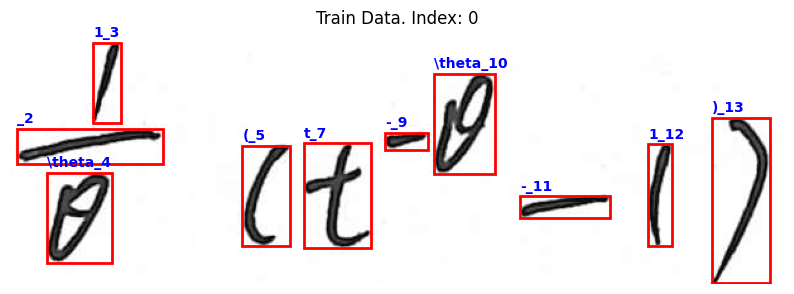

In [ ]:
# Visualize an example from the training data
visualize_parsed_data(parsed_train_data, idx=0, dataset_type="train")

Objects:
  - ID: _2, Symbol: -, Type: O
  - ID: 1_3, Symbol: 1, Type: OAbove
  - ID: \theta_4, Symbol: \theta, Type: OBelow
  - ID: (_5, Symbol: (, Type: OR
  - ID: t_7, Symbol: t, Type: ORR
  - ID: -_9, Symbol: -, Type: ORRSup
  - ID: \theta_10, Symbol: \theta, Type: ORRSupR
  - ID: -_11, Symbol: -, Type: ORRR
  - ID: 1_12, Symbol: 1, Type: ORRRR
  - ID: )_13, Symbol: ), Type: ORRRRR

Bounding Boxes:
  - Symbol: _2, Coords: (5.135, 76.5092), (120.4724, 104.7301)
  - Symbol: 1_3, Coords: (65.2577, 8.411), (87.3436, 72.2147)
  - Symbol: \theta_4, Coords: (29.0613, 111.4785), (79.9816, 183.2577)
  - Symbol: (_5, Coords: (183.6626, 90.0061), (221.6994, 169.7607)
  - Symbol: t_7, Coords: (232.1288, 88.1656), (285.5031, 170.9877)
  - Symbol: -_9, Coords: (296.546, 79.5767), (330.9018, 93.0736)
  - Symbol: \theta_10, Coords: (335.1963, 32.9509), (383.6626, 112.7055)
  - Symbol: -_11, Coords: (403.908, 129.8834), (475.0736, 147.0613)
  - Symbol: 1_12, Coords: (505.135, 88.7791), (524.1534, 16

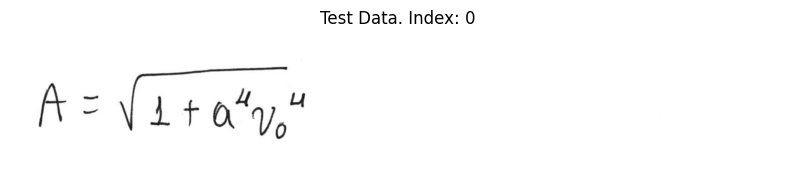

Objects:
  - ID: +_1, Symbol: +, Type: ORRInsideR
  - ID: a_1, Symbol: a, Type: ORRInsideRR
  - ID: A_1, Symbol: A, Type: O
  - ID: _1, Symbol: \sqrt, Type: ORR
  - ID: =_1, Symbol: =, Type: OR
  - ID: 1_1, Symbol: 1, Type: ORRInside
  - ID: 4_2, Symbol: 4, Type: ORRInsideRRRSup
  - ID: 0_1, Symbol: 0, Type: ORRInsideRRRSub
  - ID: u_1, Symbol: v, Type: ORRInsideRRR
  - ID: 4_1, Symbol: 4, Type: ORRInsideRRSup

Bounding Boxes:
  Bounding boxes are missing.

LaTeX Code:
  LaTeX code is missing.


In [ ]:
# Visualize an example from the test data
visualize_parsed_data(parsed_test_data, idx=0, dataset_type="test")

# Image Preprocessing

Here, we perform image preprocessing from the dataset to prepare them for use in the machine learning model. The processing includes binarization, noise removal, cropping, normalization, and resizing of images.

**Why wasn't augmentation added?**

Because the dataset already has a high level of diversity, containing a wide range of different handwriting styles and notation variations.

In [ ]:
import cv2
import numpy as np

def preprocess_image(image_path, output_size=(256, 256)):

    # 1. Load the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Failed to load file: {image_path}")

    # Check image dimensions
    h, w = image.shape
    if h == 0 or w == 0:
        raise ValueError(f"Image has zero dimensions: {image_path}")

    # 2. Noise removal (Gaussian Blur)
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # 3. Binarization
    binary = cv2.adaptiveThreshold(
        blurred,
        maxValue=255,
        adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        thresholdType=cv2.THRESH_BINARY,
        blockSize=51,
        C=10
    )

    # Invert image to make symbols white on a black background
    inverted = 255 - binary

    # 4. Find contours to extract the formula area
    contours, _ = cv2.findContours(inverted, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        x_min, y_min, x_max, y_max = float('inf'), float('inf'), float('-inf'), float('-inf')
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            x_min, y_min = min(x_min, x), min(y_min, y)
            x_max, y_max = max(x_max, x + w), max(y_max, y + h)

        # Ensure cropping does not result in an empty image
        if x_max <= x_min or y_max <= y_min:
            print(f"Cropping area is empty for file: {image_path}. Using full image.")
            cropped = binary
        else:
            cropped = binary[y_min:y_max, x_min:x_max]
    else:
        print(f"No contours found for file: {image_path}. Using full image.")
        cropped = binary

    # 5. Resizing while maintaining aspect ratio
    h, w = cropped.shape
    scale = min(output_size[1] / h, output_size[0] / w)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(cropped, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # 6. Padding to match output_size
    padded = np.ones(output_size, dtype=np.uint8) * 255
    start_x = (output_size[0] - new_w) // 2
    start_y = (output_size[1] - new_h) // 2
    padded[start_y:start_y + new_h, start_x:start_x + new_w] = resized

    # 7. Normalize pixel values
    normalized = padded.astype(np.float32) / 255.0

    return normalized

In [ ]:
def preprocess_parsed_train_data(parsed_train_data, output_size=(256, 256)):
    preprocessed_train_data = []
    for item in parsed_train_data:
        try:
            print(f"Processing image: {item['image']}")
            preprocessed_image = preprocess_image(item['image'], output_size)
            preprocessed_train_data.append({
                'image': item['image'],
                'preprocessed': preprocessed_image,
                'objects': item['objects'],
                'bounding_boxes': item['bounding_boxes'],
                'relations': item['relations'],
                'latex': item['latex']
            })
        except Exception as e:
            print(f"Error processing {item['image']}: {e}")
    return preprocessed_train_data

preprocessed_train_data = preprocess_parsed_train_data(parsed_train_data)
print(f"Preprocessed training data: {len(preprocessed_train_data)}")

Выходные данные были обрезаны до нескольких последних строк (5000).
Processing image: /content/crohme_data/TC11_CROHME23/IMG/train/OffHME/01741.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/train/OffHME/01779.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/train/OffHME/07545.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/train/OffHME/08451.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/train/OffHME/03862.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/train/OffHME/07110.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/train/OffHME/04588.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/train/OffHME/02561.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/train/OffHME/08061.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/train/OffHME/00576.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/train/OffHME/04833.png
Processing image: /content/crohme_data/TC11_CROHME23

In [ ]:
def preprocess_parsed_test_data(parsed_test_data, output_size=(256, 256)):

    preprocessed_test_data = []

    for item in parsed_test_data:
        try:
            print(f"Processing image: {item['image']}")

            # Preprocess the image
            preprocessed_image = preprocess_image(item['image'], output_size)

            # Construct dictionary with preprocessed data
            preprocessed_test_data.append({
                'image': item['image'],  # Path to the original image
                'preprocessed': preprocessed_image,  # Preprocessed image
                'objects': item.get('objects', []),  # Objects (if available)
                'bounding_boxes': item.get('bounding_boxes', []),  # Bounding boxes (empty list if missing)
                'relations': item.get('relations', []),  # Relations (if available)
                'latex': None  # Explicitly indicate that LaTeX code is missing
            })

        except Exception as e:
            print(f"Error processing {item['image']}: {e}")

    return preprocessed_test_data

preprocessed_test_data = preprocess_parsed_test_data(parsed_test_data)
print(f"Preprocessed test data: {len(preprocessed_test_data)}")

Processing image: /content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/form_343_E2740.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/form_397_E3176.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/form_5_f_238_E1188.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/form_5_731_E3654.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/form_5_f_255_E1274.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/form_336_E2685.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/form_5_738_E3686.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/form_5_f_234_E1167.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/form_5_f_733_E3661.png
Processing image: /content/crohme_data/TC11_CROHME23/IMG/test/CROHME2023_test/form_5_f_292_E1457.png
Proces

## Visualization of Preprocessed Images

In [ ]:
def visualize_preprocessed_data(preprocessed_data, idx):
    sample = preprocessed_data[idx]
    plt.figure(figsize=(8, 6))
    plt.imshow(sample['preprocessed'], cmap='gray')
    plt.title(f"Index: {idx}\nPath: {sample['image']}", fontsize=10)
    plt.axis('off')
    plt.show()

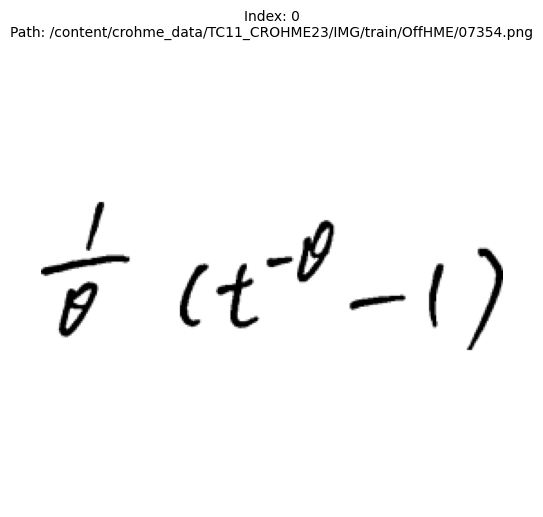

In [ ]:
# Example visualization
visualize_preprocessed_data(preprocessed_train_data, idx=0)

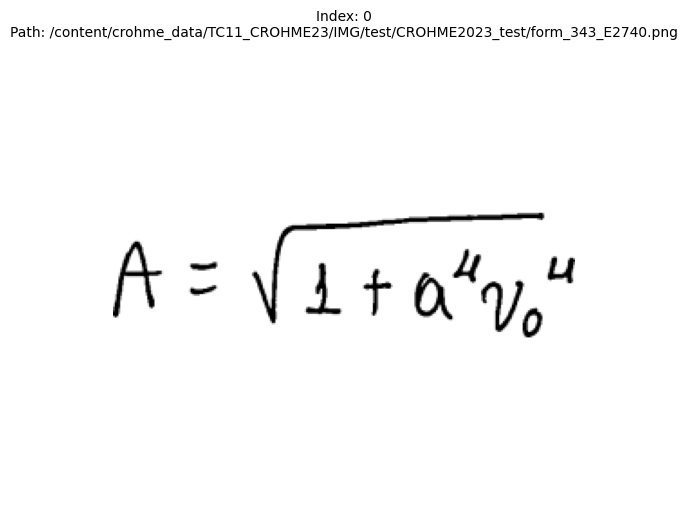

In [ ]:
# Example visualization
visualize_preprocessed_data(preprocessed_test_data, idx=0)

# Merging Preprocessed and Parsed Data

Merging parsed (parsed_data) and preprocessed (preprocessed_data) data into a unified format. As a result, each entry contains both metadata (annotations and labels) and the processed image, making it ready for use in the machine learning model.

**Why merge preprocessed and parsed data?**

Merging preprocessed and parsed data is essential to link images with their annotations, ensuring a correct match between processed pixels, object annotations, bounding box coordinates, relations, and LaTeX code. This makes the data ready for model training and simplifies further processing.

In [ ]:
def combine_parsed_and_preprocessed(parsed_data, preprocessed_data):
    if len(parsed_data) != len(preprocessed_data):
        raise ValueError("The sizes of parsed_data and preprocessed_data do not match!")

    combined_data = []
    for parsed_item, preprocessed_item in zip(parsed_data, preprocessed_data):
        if parsed_item['image'] == preprocessed_item['image']:
            combined_data.append({
                'image': parsed_item['image'],
                'preprocessed': preprocessed_item['preprocessed'],
                'objects': parsed_item['objects'],
                'bounding_boxes': parsed_item['bounding_boxes'],
                'relations': parsed_item['relations'],
                'latex': parsed_item.get('latex', None)
            })
        else:
            print(f"File mismatch: {parsed_item['image']} and {preprocessed_item['image']}")
    return combined_data

In [ ]:
# Merge training data
combined_train_data = combine_parsed_and_preprocessed(parsed_train_data, preprocessed_train_data)
print(f"Number of training data entries: {len(combined_train_data)}")

Number of training data entries: 9831


In [ ]:
# Test data remains without tokens, only with preprocessed images
combined_test_data = preprocessed_test_data
print(f"Number of test data entries: {len(combined_test_data)}")

Number of test data entries: 2297


# Data preparation and tokenization for LaTeX

We perform preprocessing of LaTeX annotations by generating tokens and converting mathematical formulas into a numerical format for model training.

## Tokenization of LaTeX Code

In [ ]:
import re

def tokenize_latex(latex_code):
    # Improved regular expression for LaTeX tokenization
    tokens = re.findall(
        r'\\[a-zA-Z]+|\\[^\\\s]|\^|_|\{|\}|\[|\]|\(|\)|\d+|[a-zA-Z]|[\+\-\*/=<>.,!]|.',
        latex_code
    )
    return [token for token in tokens if token.strip()]

In [ ]:
latex_code = r"$C _ { v L }$"
tokens = tokenize_latex(latex_code)
print(tokens)

['$', 'C', '_', '{', 'v', 'L', '}', '$']


## Creating a token dictionary

In [ ]:
def create_token_dictionary(tokenized_data):
    unique_tokens = set()
    for tokens in tokenized_data:
        unique_tokens.update(tokens)

    # Add special tokens, including <UNK>
    special_tokens = ["<PAD>", "<START>", "<END>", "<UNK>"]
    unique_tokens.update(special_tokens)

    # Create a dictionary with sorted tokens
    sorted_tokens = sorted(unique_tokens)  # Lexicographic sorting
    token_to_index = {token: idx for idx, token in enumerate(sorted_tokens)}
    index_to_token = {idx: token for token, idx in token_to_index.items()}

    return token_to_index, index_to_token

In [ ]:
tokenized_data = [["$", "C", "_", "{", "v", "L", "}", "$"], ["$", "a", "+", "b", "$"]]
token_to_index, index_to_token = create_token_dictionary(tokenized_data)
print(token_to_index)

{'$': 0, '+': 1, '<END>': 2, '<PAD>': 3, '<START>': 4, '<UNK>': 5, 'C': 6, 'L': 7, '_': 8, 'a': 9, 'b': 10, 'v': 11, '{': 12, '}': 13}


## Encoding LaTeX code

In [ ]:
def encode_latex(tokens, token_to_index, max_length=85):
    # Add special tokens <START> and <END>
    encoded = [token_to_index["<START>"]]
    for token in tokens:
        if token in token_to_index:
            encoded.append(token_to_index[token])
        else:
            encoded.append(token_to_index["<UNK>"])  # Replace unknown token with <UNK>
    encoded.append(token_to_index["<END>"])

    # Limit sequence length
    if len(encoded) > max_length:
        encoded = encoded[:max_length]
    else:
        encoded += [token_to_index["<PAD>"]] * (max_length - len(encoded))

    return encoded

In [ ]:
tokens = ["$", "C", "_", "{", "v", "L", "}", "$"]
encoded = encode_latex(tokens, token_to_index, max_length=10)
print(encoded)

[4, 0, 6, 8, 12, 11, 7, 13, 0, 2]


In [ ]:
tokens_with_unknown = ["$", "C", ",", "{", "v", "L", "}", "$"]
encoded_with_unknown = encode_latex(tokens_with_unknown, token_to_index, max_length=10)
print(encoded_with_unknown)

[4, 0, 6, 5, 12, 11, 7, 13, 0, 2]


## Processing training data

In [ ]:
def prepare_train_data(combined_train_data, max_length=85):
    # Extract and tokenize LaTeX code
    tokenized_data = []
    for item in combined_train_data:
        if item['latex']:
            tokenized_data.append(tokenize_latex(item['latex']))

    # Create token dictionary
    token_to_index, index_to_token = create_token_dictionary(tokenized_data)

    # Encode LaTeX code
    prepared_data = []
    for item in combined_train_data:
        if item['latex']:
            tokens = tokenize_latex(item['latex'])
            encoded = encode_latex(tokens, token_to_index, max_length)
            prepared_data.append({
                'image': item['preprocessed'],
                'encoded_latex': encoded,
                'objects': item['objects'],
                'bounding_boxes': item['bounding_boxes'],
                'relations': item['relations']
            })
        else:
            print(f"LaTeX code missing for file: {item['image']}")

    return prepared_data, token_to_index, index_to_token

In [ ]:
# Prepare training data
prepared_train_data, token_to_index, index_to_token = prepare_train_data(combined_train_data)
print(f"Prepared training data: {len(prepared_train_data)}")

Prepared training data: 9831


In [ ]:
# Test data remains unchanged
prepared_test_data = combined_test_data
print(f"Prepared test data: {len(prepared_test_data)}")

Prepared test data: 2297


In [ ]:
# Checking the first few training data items
for i, item in enumerate(prepared_train_data[:5]):
    print(f"Data item {i}:")
    print(f"Image shape: {item['image'].shape}")
    print(f"Encoded LaTeX: {item['encoded_latex']}")
    print(f"Objects: {[obj['symbol'] for obj in item['objects']]}")
    print(f"Bounding Boxes: {[(bbox['x_min'], bbox['y_min'], bbox['x_max'], bbox['y_max']) for bbox in item['bounding_boxes']]}")
    print(f"Relations: {[(rel['from'], rel['to'], rel['relation']) for rel in item['relations']]}")
    print("-" * 50)

Data item 0:
Image shape: (256, 256)
Encoded LaTeX: [22, 1, 52, 107, 10, 109, 107, 74, 109, 2, 100, 79, 107, 6, 74, 109, 6, 10, 3, 1, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
Objects: ['-', '1', '\\theta', '(', 't', '-', '\\theta', '-', '1', ')']
Bounding Boxes: [(5.135, 76.5092, 120.4724, 104.7301), (65.2577, 8.411, 87.3436, 72.2147), (29.0613, 111.4785, 79.9816, 183.2577), (183.6626, 90.0061, 221.6994, 169.7607), (232.1288, 88.1656, 285.5031, 170.9877), (296.546, 79.5767, 330.9018, 93.0736), (335.1963, 32.9509, 383.6626, 112.7055), (403.908, 129.8834, 475.0736, 147.0613), (505.135, 88.7791, 524.1534, 169.7607), (555.4417, 67.9202, 602.0, 199.0)]
Relations: [('(_5', 't_7', 'Right'), ('-_11', '1_12', 'Right'), ('-_9', '\\theta_10', 'Right'), ('1_12', ')_13', 'Right'), ('

In [ ]:
# Checking token-to-index mapping
for token, index in token_to_index.items():
    print(f"Token: {token}, Index: {index}")

Token: !, Index: 0
Token: $, Index: 1
Token: (, Index: 2
Token: ), Index: 3
Token: +, Index: 4
Token: ,, Index: 5
Token: -, Index: 6
Token: ., Index: 7
Token: /, Index: 8
Token: 0, Index: 9
Token: 1, Index: 10
Token: 2, Index: 11
Token: 3, Index: 12
Token: 4, Index: 13
Token: 5, Index: 14
Token: 6, Index: 15
Token: 7, Index: 16
Token: 8, Index: 17
Token: 9, Index: 18
Token: <, Index: 19
Token: <END>, Index: 20
Token: <PAD>, Index: 21
Token: <START>, Index: 22
Token: <UNK>, Index: 23
Token: =, Index: 24
Token: >, Index: 25
Token: A, Index: 26
Token: B, Index: 27
Token: C, Index: 28
Token: E, Index: 29
Token: F, Index: 30
Token: G, Index: 31
Token: H, Index: 32
Token: I, Index: 33
Token: L, Index: 34
Token: M, Index: 35
Token: N, Index: 36
Token: P, Index: 37
Token: R, Index: 38
Token: S, Index: 39
Token: T, Index: 40
Token: V, Index: 41
Token: X, Index: 42
Token: Y, Index: 43
Token: [, Index: 44
Token: \Delta, Index: 45
Token: \alpha, Index: 46
Token: \beta, Index: 47
Token: \cos, Index

In [ ]:
# Checking object and bounding box consistency
for obj, bbox in zip(prepared_train_data[0]['objects'], prepared_train_data[0]['bounding_boxes']):
    print(f"Object: {obj['symbol']}, BBox: ({bbox['x_min']}, {bbox['y_min']}, {bbox['x_max']}, {bbox['y_max']})")

Object: -, BBox: (5.135, 76.5092, 120.4724, 104.7301)
Object: 1, BBox: (65.2577, 8.411, 87.3436, 72.2147)
Object: \theta, BBox: (29.0613, 111.4785, 79.9816, 183.2577)
Object: (, BBox: (183.6626, 90.0061, 221.6994, 169.7607)
Object: t, BBox: (232.1288, 88.1656, 285.5031, 170.9877)
Object: -, BBox: (296.546, 79.5767, 330.9018, 93.0736)
Object: \theta, BBox: (335.1963, 32.9509, 383.6626, 112.7055)
Object: -, BBox: (403.908, 129.8834, 475.0736, 147.0613)
Object: 1, BBox: (505.135, 88.7791, 524.1534, 169.7607)
Object: ), BBox: (555.4417, 67.9202, 602.0, 199.0)


## Checking the number of tokens in the dictionary

In [ ]:
print(f"Number of tokens in the dictionary: {len(token_to_index)}")

Number of tokens in the dictionary: 110


## Checking the number of encoded training and test data

In [ ]:
print(f"Number of encoded training data: {len(prepared_train_data)}")

Number of encoded training data: 9831


In [ ]:
print(f"Number of test data: {len(prepared_test_data)}")

Number of test data: 2297


## Additional check

In [ ]:
# Checking the first element in prepared_train_data
sample = prepared_train_data[1]
print("Example of encoded data:")
print(f"Image shape: {sample['image'].shape}")
print(f"Encoded LaTeX: {sample['encoded_latex']}")
print(f"Objects: {sample['objects']}")
print(f"Bounding Boxes: {sample['bounding_boxes']}")
print(f"Relations: {sample['relations']}")

Example of encoded data:
Image shape: (256, 256)
Encoded LaTeX: [22, 1, 87, 79, 107, 9, 9, 109, 1, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
Objects: [{'id': 'g_2', 'symbol': 'g', 'probability': 1.0, 'type': 'O'}, {'id': '0_4', 'symbol': '0', 'probability': 1.0, 'type': 'OSup'}, {'id': '0_5', 'symbol': '0', 'probability': 1.0, 'type': 'OSupR'}]
Bounding Boxes: [{'symbol': 'g_2', 'x_min': 54.5627, 'y_min': 30.8244, 'x_max': 12.8065, 'y_max': 149.2832}, {'symbol': '0_4', 'x_min': 62.2688, 'y_min': 53.405, 'x_max': 94.5269, 'y_max': 6.6308}, {'symbol': '0_5', 'x_min': 101.8746, 'y_min': 6.9892, 'x_max': 133.0573, 'y_max': 54.6595}]
Relations: [{'from': '0_4', 'to': '0_5', 'relation': 'Right', 'probability': 1.0}, {'from': 'g_2', 't

## Token distribution analysis

In [ ]:
from collections import Counter

def analyze_token_distribution(prepared_train_data, token_to_index):
    index_to_token = {idx: token for token, idx in token_to_index.items()}
    token_counts = Counter()

    for item in prepared_train_data:
        encoded_latex = item['encoded_latex']
        tokens = [index_to_token[idx] for idx in encoded_latex if idx != token_to_index["<PAD>"]]
        token_counts.update(tokens)

    # Display the frequency of each token
    print("Token Distribution:")
    for token, count in token_counts.most_common():
        print(f"{token}: {count}")

# Call the function
analyze_token_distribution(prepared_train_data, token_to_index)

Token Distribution:
$: 19662
{: 16973
}: 16973
<START>: 9831
<END>: 9831
_: 8587
(: 5528
): 5528
1: 5523
2: 4859
=: 4827
^: 4612
x: 3374
,: 3124
-: 3067
+: 2874
0: 2460
n: 2384
a: 1684
i: 1676
\frac: 1637
t: 1393
3: 1304
k: 1228
d: 1190
y: 1109
p: 1052
r: 1002
f: 943
m: 933
b: 912
c: 905
/: 889
A: 755
s: 700
4: 696
T: 668
|: 662
e: 654
v: 627
z: 603
\ldots: 603
P: 600
5: 534
j: 522
S: 519
N: 517
\alpha: 508
C: 502
X: 501
\sqrt: 500
u: 494
V: 468
q: 466
E: 464
B: 454
F: 438
g: 437
[: 437
]: 437
L: 420
h: 409
M: 391
.: 388
\theta: 387
6: 368
\pi: 365
G: 359
R: 333
<: 332
w: 330
H: 329
\sigma: 323
\sum: 318
I: 313
\prime: 311
\Delta: 295
\leq: 292
l: 287
7: 287
\beta: 276
\infty: 256
\times: 253
8: 241
\mu: 240
\gamma: 224
\phi: 220
\{: 211
\}: 211
o: 202
Y: 199
\sin: 183
>: 178
\cos: 176
9: 176
\geq: 148
\log: 144
\rightarrow: 134
\pm: 134
\int: 130
\in: 109
\lim: 68
\neq: 67
!: 54
\tan: 21
\forall: 14
\div: 11
\exists: 3


## Checking maximum sequence length

In [ ]:
def analyze_sequence_lengths(prepared_train_data, token_to_index):
    if not prepared_train_data:
        print("prepared_train_data is empty!")
        return

    # Check for the presence of the 'encoded_latex' key
    if 'encoded_latex' not in prepared_train_data[0]:
        print("Key 'encoded_latex' is missing in the data!")
        return

    # Extract sequence lengths excluding <PAD>
    lengths = []
    for item in prepared_train_data:
        encoded_latex = item['encoded_latex']
        length = len([token for token in encoded_latex if token != token_to_index["<PAD>"]])
        lengths.append(length)

    # Print sequence length statistics
    if lengths:
        print("Sequence Length Statistics:")
        print(f"Minimum length: {min(lengths)}")
        print(f"Maximum length: {max(lengths)}")
        print(f"Average length: {sum(lengths) / len(lengths):.2f}")
    else:
        print("Failed to extract sequence lengths.")

In [ ]:
analyze_sequence_lengths(prepared_train_data, token_to_index)

Sequence Length Statistics:
Minimum length: 7
Maximum length: 81
Average length: 17.67


In [ ]:
# Compute sequence lengths excluding <PAD>
lengths = []
for item in prepared_train_data:
    encoded_latex = item['encoded_latex']
    length = len([token for token in encoded_latex if token != token_to_index["<PAD>"]])
    lengths.append(length)

# Check the number of truncated sequences
long_sequences = [length for length in lengths if length == 85]
print(f"Number of truncated sequences: {len(long_sequences)}")

Number of truncated sequences: 0


## Visualization of sequence length distribution

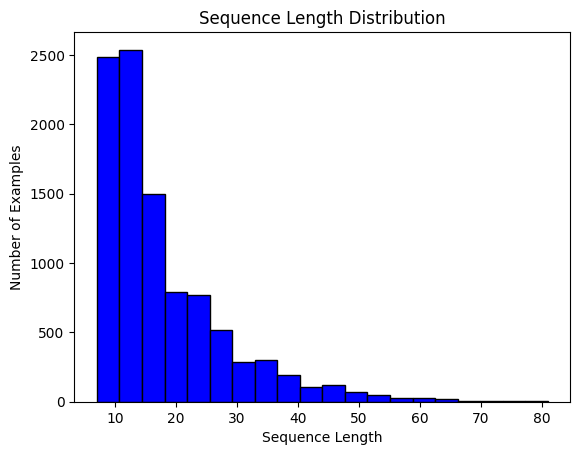

In [ ]:
import matplotlib.pyplot as plt

plt.hist(lengths, bins=20, color='blue', edgecolor='black')
plt.title("Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Number of Examples")
plt.show()

# Data normalization (bounding boxes)

We normalize bounding box coordinates by scaling them to the range [0, 1] relative to the image size (256x256).

**Why Normalize Bounding Boxes?**

Normalization makes bounding boxes independent of image size, improves model training, speeds up optimization, and ensures compatibility with neural network models.

In [ ]:
def normalize_bounding_boxes(data):
    for item in data:
        for bbox in item['bounding_boxes']:
            bbox['x_min'] /= 256
            bbox['y_min'] /= 256
            bbox['x_max'] /= 256
            bbox['y_max'] /= 256
    return data

# Normalize bounding box coordinates
prepared_train_data = normalize_bounding_boxes(prepared_train_data)

In [ ]:
# Check the first few data items
for i, item in enumerate(prepared_train_data[:5]):
    print(f"Data item {i}:")
    for bbox in item['bounding_boxes']:
        print(f"Bounding Box: ({bbox['x_min']:.3f}, {bbox['y_min']:.3f}, {bbox['x_max']:.3f}, {bbox['y_max']:.3f})")
    print("-" * 50)

Data item 0:
Bounding Box: (0.020, 0.299, 0.471, 0.409)
Bounding Box: (0.255, 0.033, 0.341, 0.282)
Bounding Box: (0.114, 0.435, 0.312, 0.716)
Bounding Box: (0.717, 0.352, 0.866, 0.663)
Bounding Box: (0.907, 0.344, 1.115, 0.668)
Bounding Box: (1.158, 0.311, 1.293, 0.364)
Bounding Box: (1.309, 0.129, 1.499, 0.440)
Bounding Box: (1.578, 0.507, 1.856, 0.574)
Bounding Box: (1.973, 0.347, 2.047, 0.663)
Bounding Box: (2.170, 0.265, 2.352, 0.777)
--------------------------------------------------
Data item 1:
Bounding Box: (0.213, 0.120, 0.050, 0.583)
Bounding Box: (0.243, 0.209, 0.369, 0.026)
Bounding Box: (0.398, 0.027, 0.520, 0.214)
--------------------------------------------------
Data item 2:
Bounding Box: (0.087, 0.032, 0.143, 0.510)
Bounding Box: (0.212, 0.142, 0.429, 0.464)
Bounding Box: (0.508, 0.356, 0.633, 0.525)
Bounding Box: (0.776, 0.287, 0.924, 0.344)
Bounding Box: (1.031, 0.208, 1.259, 0.550)
Bounding Box: (1.427, 0.058, 1.491, 0.630)
Bounding Box: (1.779, 0.351, 2.070, 0.630)

# Splitting data into Training and Validation sets

In [ ]:
# random_state=42: Ensures reproducibility of the split.
from sklearn.model_selection import train_test_split

# Splitting the data into training and validation sets
train_data, val_data = train_test_split(prepared_train_data, test_size=0.2, random_state=42)

print(f"Training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")
print(f"Test set size: {len(prepared_test_data)}")

Training set size: 7864
Validation set size: 1967
Test set size: 2297


# Converting data to tensors

Converting images, bounding boxes, relations, and LaTeX tokens into PyTorch tensors for model training.

Converting data into tensors is necessary for compatibility with PyTorch, optimization of computations on the GPU, and unifying the data format, including images, bounding boxes, relations, and LaTeX tokens, enabling efficient model training.

In [ ]:
import torch
from torchvision import transforms
import numpy as np
from PIL import Image
import os

# Transforming images into tensors
transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB") if isinstance(img, Image.Image) else img),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

def prepare_images(data):
    images_tensor = []

    for item in data:
        image = item['image']

        # If the image is a string, load it
        if isinstance(image, str):
            if not os.path.exists(image):
                raise FileNotFoundError(f"File not found: {image}")
            image = Image.open(image).convert("RGB")  # Open and convert to RGB

        # If the image is a numpy.ndarray, convert it to PIL.Image
        elif isinstance(image, np.ndarray):
            image = Image.fromarray(image)

        image = transform(image)  # Apply transformations
        images_tensor.append(image)

    return torch.stack(images_tensor)  # (num_samples, channels, height, width)

def prepare_bboxes(data):
    max_boxes = max(len(item['bounding_boxes']) for item in data)
    bboxes_tensor = []
    for item in data:
        boxes = item['bounding_boxes']
        if len(boxes) == 0:
            boxes = [{'x_min': 0, 'y_min': 0, 'x_max': 0, 'y_max': 0}]
        padded_boxes = boxes + [{'x_min': 0, 'y_min': 0, 'x_max': 0, 'y_max': 0}] * (max_boxes - len(boxes))
        bbox_tensor = torch.tensor([[box['x_min'], box['y_min'], box['x_max'], box['y_max']] for box in padded_boxes], dtype=torch.float32)
        bboxes_tensor.append(bbox_tensor)
    return torch.stack(bboxes_tensor)

def prepare_relations(data):
    max_relations = max(len(item['relations']) for item in data)
    relations_tensor = []

    for item in data:
        relations = item['relations']

        # If the relations list is empty, add a dummy relation
        if len(relations) == 0:
            relations = [{'from': 0, 'to': 0, 'relation': 0, 'probability': 0.0}]

        # Pad to max_relations
        padded_relations = relations + [{'from': 0, 'to': 0, 'relation': 0, 'probability': 0.0}] * (max_relations - len(relations))

        # Convert text identifiers into numerical values
        relation_tensor = torch.tensor([
            [hash(relation['from']) % 100000,  # Limit hash size
             hash(relation['to']) % 100000,
             hash(relation['relation']) % 100000,
             float(relation['probability'])]  # Convert probability to float
            for relation in padded_relations
        ], dtype=torch.float32)

        relations_tensor.append(relation_tensor)

    return torch.stack(relations_tensor)  # (num_samples, num_relations, 4)

def prepare_targets(data, max_length):
    if isinstance(max_length, list):  # Check if max_length is a list instead of int
        max_length = max(max_length)  # Take the maximum value

    targets_tensor = []
    pad_token = token_to_index.get("<PAD>", 0)  # Default to 0 if "<PAD>" is missing

    for item in data:
        target = item.get('encoded_latex', [])
        if not isinstance(target, list):  # Ensure target is a list
            target = [pad_token]

        padded_target = target + [pad_token] * (max_length - len(target))
        targets_tensor.append(torch.tensor(padded_target, dtype=torch.long))

    return torch.stack(targets_tensor)

# Preparing data for Train and Validation (includes everything)
train_images = prepare_images(train_data)
train_bboxes = prepare_bboxes(train_data)
train_relations = prepare_relations(train_data)
train_targets = prepare_targets(train_data, 85)

val_images = prepare_images(val_data)
val_bboxes = prepare_bboxes(val_data)
val_relations = prepare_relations(val_data)
val_targets = prepare_targets(val_data, 85)

# Preparing data for Test (only images and Relations)
test_images = prepare_images(prepared_test_data)
test_relations = prepare_relations(prepared_test_data)

# Checking tensor dimensions
print("Train Images shape:", train_images.shape)
print("Validation Images shape:", val_images.shape)
print("Test Images shape:", test_images.shape)

print("Train Relations shape:", train_relations.shape)
print("Validation Relations shape:", val_relations.shape)
print("Test Relations shape:", test_relations.shape)

print("Train BBoxes shape:", train_bboxes.shape)
print("Validation BBoxes shape:", val_bboxes.shape)

print("Train Targets shape:", train_targets.shape)
print("Validation Targets shape:", val_targets.shape)

Train Images shape: torch.Size([7864, 3, 256, 256])
Validation Images shape: torch.Size([1967, 3, 256, 256])
Test Images shape: torch.Size([2297, 3, 256, 256])
Train Relations shape: torch.Size([7864, 45, 4])
Validation Relations shape: torch.Size([1967, 47, 4])
Test Relations shape: torch.Size([2297, 43, 4])
Train BBoxes shape: torch.Size([7864, 46, 4])
Validation BBoxes shape: torch.Size([1967, 48, 4])
Train Targets shape: torch.Size([7864, 85])
Validation Targets shape: torch.Size([1967, 85])


# Creating Datasets and Data Loaders

In [ ]:
import os
import torch
from PIL import Image
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CustomDataset(Dataset):
    def __init__(self, data, transform=None, mode='train'):
        self.data = data
        self.transform = transform
        self.mode = mode

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        # Process image
        image = sample['image']
        if isinstance(image, str):
            if not os.path.exists(image):
                raise FileNotFoundError(f"File not found: {image}")
            image = Image.open(image).convert("RGB")
        elif isinstance(image, np.ndarray):
            image = Image.fromarray((image * 255).astype(np.uint8))

        if self.transform:
            image = self.transform(image)

        if self.mode == 'train':
            # Load bounding boxes and relations
            bounding_boxes = torch.tensor(
                [[bbox['x_min'], bbox['y_min'], bbox['x_max'], bbox['y_max']] for bbox in sample['bounding_boxes']],
                dtype=torch.float32
            )

            relations = torch.tensor(
                [[hash(rel['from']) % 100000, hash(rel['to']) % 100000, hash(rel['relation']) % 100000, float(rel['probability'])]
                 for rel in sample['relations']], dtype=torch.float32
            )

            # Use precomputed encoded LaTeX sequence
            encoded_latex = torch.tensor(sample['encoded_latex'], dtype=torch.long)

            return image, bounding_boxes, relations, encoded_latex
        else:
            relations = torch.tensor(
                [[hash(rel['from']) % 100000, hash(rel['to']) % 100000, hash(rel['relation']) % 100000, float(rel['probability'])]
                 for rel in sample['relations']], dtype=torch.float32
            )
            return image, relations



def pad_collate_fn(batch):
    # Determine the number of elements in a sample
    sample_len = len(batch[0])

    if sample_len == 4:
        images, bboxes, relations, latex = [], [], [], []
        max_bboxes = max(len(b[1]) for b in batch)
        max_relations = max(len(b[2]) for b in batch)

        for img, bbox, rel, la in batch:
            images.append(img)
            # Padding for bounding boxes
            pad_bbox = torch.zeros((max_bboxes, 4), dtype=torch.float32)
            pad_bbox[:len(bbox)] = bbox
            bboxes.append(pad_bbox)
            # Padding for relations
            pad_rel = torch.zeros((max_relations, 4), dtype=torch.float32)
            pad_rel[:len(rel)] = rel
            relations.append(pad_rel)
            latex.append(la)

        return torch.stack(images), torch.stack(bboxes), torch.stack(relations), torch.stack(latex)

    elif sample_len == 2:
        images, relations = [], []
        max_relations = max(len(b[1]) for b in batch)
        for img, rel in batch:
            images.append(img)
            pad_rel = torch.zeros((max_relations, 4), dtype=torch.float32)
            pad_rel[:len(rel)] = rel
            relations.append(pad_rel)
        return torch.stack(images), torch.stack(relations)

    else:
        raise ValueError(f"Unexpected number of elements in a batch sample: {sample_len}")



# Data Preprocessing
# Define transformations for images (Convert 1-channel to 3-channel)
data_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Grayscale(num_output_channels=3),  # Convert 1-channel image to 3-channel
    transforms.ToTensor(),
])

# Vocabulary size
vocab_size = len(token_to_index)

# Define indices for special tokens
pad_token = token_to_index["<PAD>"]

# Updating train_data without re-tokenization
for sample in train_data:
    sample["encoded_latex"] = sample["encoded_latex"]

for sample in val_data:
    sample["encoded_latex"] = sample["encoded_latex"]

# Processing test data
for sample in prepared_test_data:
    if "latex" in sample and sample["latex"] is not None:
        sample["encoded_latex"] = encode_latex(tokenize_latex(sample["latex"]), token_to_index)
    else:
        sample["encoded_latex"] = [pad_token] * 85  # Empty sequence

    # If bounding_boxes are missing, create an empty list
    if "bounding_boxes" not in sample or len(sample["bounding_boxes"]) == 0:
        sample["bounding_boxes"] = []


# Dataset & DataLoader Creation
# Creating dataset instances
train_dataset = CustomDataset(train_data, transform=data_transforms, mode='train')
val_dataset = CustomDataset(val_data, transform=data_transforms, mode='train')
test_dataset = CustomDataset(prepared_test_data, transform=data_transforms, mode='test')

# Creating DataLoaders with custom collate function
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, collate_fn=pad_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, collate_fn=pad_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, collate_fn=pad_collate_fn)

# Check data loading
sample_batch = next(iter(train_loader))
print(f"Train batch shapes: Image: {sample_batch[0].shape}, BBoxes: {sample_batch[1].shape}, Relations: {sample_batch[2].shape}, LaTeX: {sample_batch[3].shape}")

Train batch shapes: Image: torch.Size([32, 3, 256, 256]), BBoxes: torch.Size([32, 22, 4]), Relations: torch.Size([32, 21, 4]), LaTeX: torch.Size([32, 85])


# Model architecture definition (Training + Testing)

## Model Training

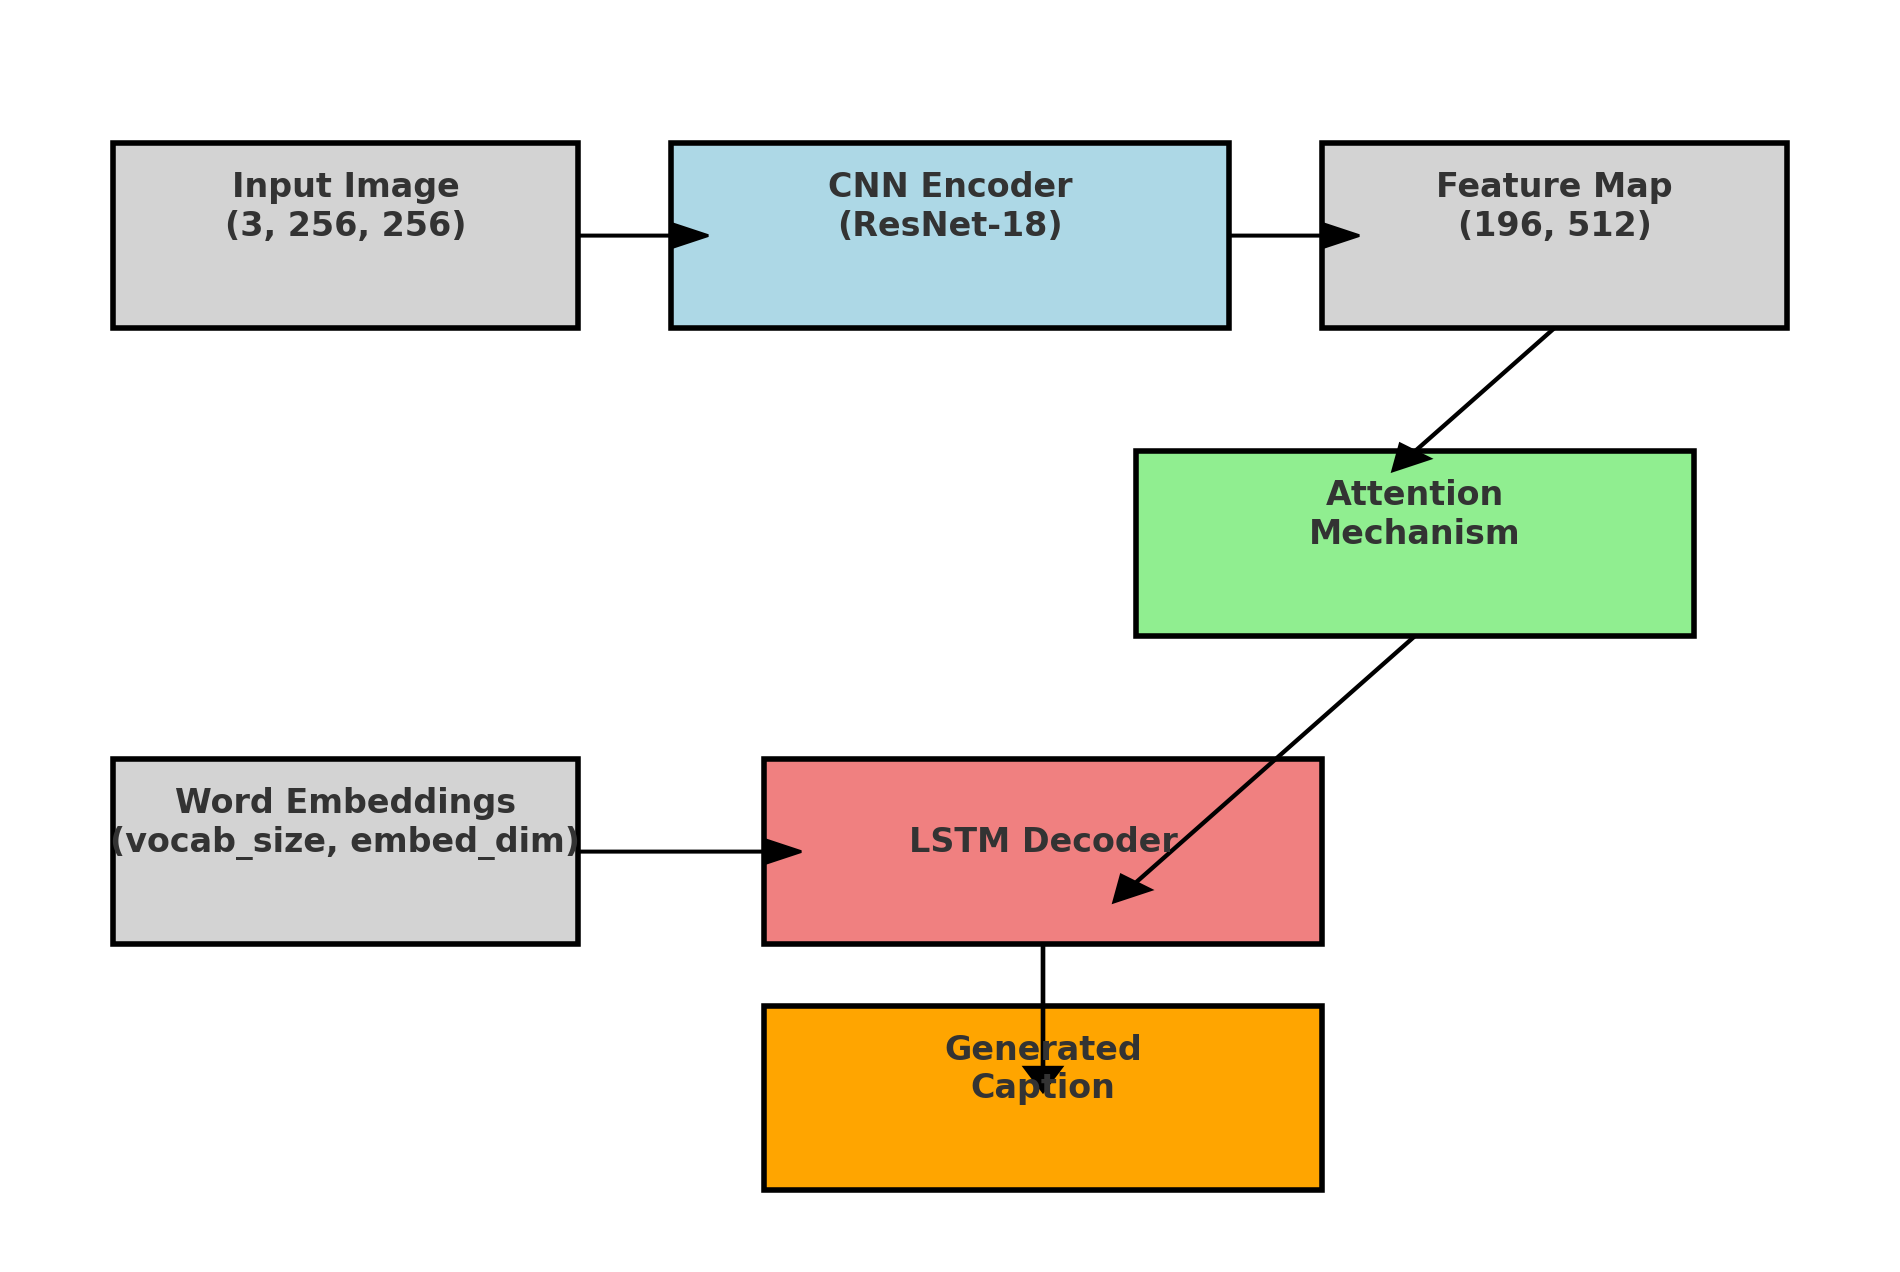

1. CNN Encoder (CNNEncoder)
- Based on ResNet-18 for extracting features from an image.
- Transforms input images into a sequence of features with shape (batch, num_pixels, encoder_dim).

The extracted features are computed as:
$$F = \text{CNN}(I) \in \mathbb{R}^{B \times C \times H' \times W'}$$
- $I$ is the input image
- $B$ is the batch size
- $C$ is the feature dimension (typically 512 for ResNet-18)
- $H', W'$ spatial dimensions after Adaptive Average Pooling

These features are then reshaped into a sequence:
$$F' = \text{reshape}(F) \in \mathbb{R}^{B \times (H'W') \times C}$$


2. Attention Module (Attention)
- Additive attention mechanism to focus on the most relevant regions of the image at each decoding step.
- Returns a weighted feature representation and attention coefficients.

a. The encoder features and decoder hidden state are projected into a common latent space:
$$e_{i,t} = W_e F_i + W_d h_t$$
Then, ReLU is applied before the final projection.

b. The attention weights are computed using the softmax function:
$$\alpha_{i,t} = \frac{\exp(e_{i,t})}{\sum_{j} \exp(e_{j,t})}$$

c. The final attention-weighted encoding is computed as: $$z_t = \sum_{i} \alpha_{i,t} F_i$$



3. LSTM Decoder (DecoderWithAttention)
- Generates a LaTeX sequence using an LSTM with attention.
- Input: LaTeX tokens (vector representation) and encoded image features.
- Output: predicted token probabilities, attention weights, and predicted sequence lengths.

a. The attention mechanism computes the context vector $z_t$.

b. The input vector is formed by concatenating the embedding of the previous token with the context vector: $$x_t = [\text{Embed}(y_{t-1}), z_t]$$

c. The LSTM updates its hidden state: $$ h_t, c_t = \text{LSTM}(x_t, (h_{t-1}, c_{t-1}))$$

d. Before using the context vector, an additional gating factor is applied:$$\hat{z}_t = \sigma(W_f h_t) \cdot z_t$$

e. The output layer computes token probabilities:$$p_t = \text{softmax}(W_o h_t)$$




4. Combined Model (VisiontoMathModel)
- Combines the CNN encoder and LSTM decoder with attention.
- Takes an image as input and outputs the generated LaTeX sequence.

a. The image is passed through the CNN encoder, extracting features $F$.

b. The LSTM decoder generates the sequence step by step, using the attention mechanism.

c. The optimization is performed with the loss function: $$\mathcal{L} = - \sum_{t} \log p(y_t \mid y_{<t}, I)$$
where $p(y_t)$ is the predicted probability of token $y_t$.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# 1.1. Encoder: CNN based on ResNet-18
class CNNEncoder(nn.Module):
    def __init__(self, encoded_image_size=14):
        super(CNNEncoder, self).__init__()
        self.enc_image_size = encoded_image_size
        resnet = models.resnet18(pretrained=True)
        # Remove the last layers (avgpool and fc)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))

    def forward(self, images):
        features = self.resnet(images)  # (batch, 512, H, W)
        features = self.adaptive_pool(features)  # (batch, 512, encoded_image_size, encoded_image_size)
        batch_size, encoder_dim, H, W = features.size()
        # Convert spatial dimensions into a sequence (batch, num_pixels, encoder_dim)
        features = features.view(batch_size, encoder_dim, -1).permute(0, 2, 1)
        return features

# 1.2. Attention Module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)  # Projects encoder features
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)  # Projects decoder hidden state
        self.full_att = nn.Linear(attention_dim, 1)  # Computes scalar value for each pixel
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)  # (batch, num_pixels, attention_dim)
        att2 = self.decoder_att(decoder_hidden)  # (batch, attention_dim)
        att2 = att2.unsqueeze(1)  # (batch, 1, attention_dim)
        att = self.full_att(self.relu(att1 + att2)).squeeze(2)  # (batch, num_pixels)
        alpha = self.softmax(att)  # (batch, num_pixels)
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  # (batch, encoder_dim)
        return attention_weighted_encoding, alpha

# 1.3. Decoder with Attention (LSTM-based)
class DecoderWithAttention(nn.Module):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=512, dropout=0.5):
        super(DecoderWithAttention, self).__init__()
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)  # Attention module

        self.embedding = nn.Embedding(vocab_size, embed_dim)  # Token embedding for input tokens
        self.dropout = nn.Dropout(dropout)
        # LSTMCell takes concatenated embedding and attention context vector as input
        self.decode_step = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim, bias=True)
        # Initialize hidden states using the mean of encoder features
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        # Additional linear layer for attention gating mechanism
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()
        # Final layer to convert LSTM output into vocabulary probabilities
        self.fc = nn.Linear(decoder_dim, vocab_size)

        self.init_weights()

    def init_weights(self):
        self.embedding.weight.data.uniform_(-0.1, 0.1)
        self.fc.bias.data.fill_(0)
        self.fc.weight.data.uniform_(-0.1, 0.1)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)  # (batch, decoder_dim)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, encoded_captions, caption_lengths):
        batch_size = encoder_out.size(0)
        encoder_dim = encoder_out.size(-1)
        vocab_size = self.fc.out_features

        # Sort data by decreasing sequence length
        caption_lengths, sort_ind = caption_lengths.sort(dim=0, descending=True)
        encoder_out = encoder_out[sort_ind]
        encoded_captions = encoded_captions[sort_ind]

        # Initialize LSTM hidden states
        h, c = self.init_hidden_state(encoder_out)

        # Determine max decoding length (excluding <START>)
        decode_lengths = (caption_lengths - 1).tolist()

        # Create tensor for storing predictions
        max_decode_length = max(decode_lengths)
        predictions = torch.zeros(batch_size, max_decode_length, vocab_size).to(encoder_out.device)
        alphas = torch.zeros(batch_size, max_decode_length, encoder_out.size(1)).to(encoder_out.device)

        # Get embeddings for token sequences
        embeddings = self.embedding(encoded_captions)  # (batch, max_caption_length, embed_dim)

        # Decoding step-by-step
        for t in range(max_decode_length):
            batch_size_t = sum([l > t for l in decode_lengths])
            attention_weighted_encoding, alpha = self.attention(encoder_out[:batch_size_t], h[:batch_size_t])
            gate = self.sigmoid(self.f_beta(h[:batch_size_t]))
            attention_weighted_encoding = gate * attention_weighted_encoding
            # LSTM input: embedding of the current token + attention context
            input_lstm = torch.cat([embeddings[:batch_size_t, t, :], attention_weighted_encoding], dim=1)
            h, c = self.decode_step(input_lstm, (h[:batch_size_t], c[:batch_size_t]))
            preds = self.fc(self.dropout(h))
            predictions[:batch_size_t, t, :] = preds
            alphas[:batch_size_t, t, :] = alpha

        return predictions, encoded_captions, decode_lengths, alphas, sort_ind

# 1.4. Combined Model (Encoder + Decoder)
class VisiontoMathModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, decoder_dim, attention_dim, encoder_dim=512, dropout=0.5):
        super(VisiontoMathModel, self).__init__()
        self.encoder = CNNEncoder()
        self.decoder = DecoderWithAttention(attention_dim, embed_dim, decoder_dim,
                                            vocab_size, encoder_dim, dropout)

    def forward(self, images, encoded_captions, caption_lengths):
        encoder_out = self.encoder(images)  # (batch, num_pixels, encoder_dim)
        outputs = self.decoder(encoder_out, encoded_captions, caption_lengths)
        return outputs

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20 -- Train Loss: 50.6045, Val Loss: 39.6157
Epoch 2/20 -- Train Loss: 33.3438, Val Loss: 29.1549
Epoch 3/20 -- Train Loss: 25.5409, Val Loss: 24.6434
Epoch 4/20 -- Train Loss: 20.8822, Val Loss: 21.9051
Epoch 5/20 -- Train Loss: 17.6108, Val Loss: 19.4956
Epoch 6/20 -- Train Loss: 15.2016, Val Loss: 17.7483
Epoch 7/20 -- Train Loss: 13.0002, Val Loss: 16.7310
Epoch 8/20 -- Train Loss: 11.5024, Val Loss: 16.7885
Epoch 9/20 -- Train Loss: 10.0299, Val Loss: 15.7295
Epoch 10/20 -- Train Loss: 8.8456, Val Loss: 15.0904
Epoch 11/20 -- Train Loss: 7.8713, Val Loss: 14.6331
Epoch 12/20 -- Train Loss: 7.0097, Val Loss: 14.8857
Epoch 13/20 -- Train Loss: 6.0032, Val Loss: 14.2053
Epoch 14/20 -- Train Loss: 5.4713, Val Loss: 14.6736
Epoch 15/20 -- Train Loss: 5.2162, Val Loss: 14.2115
Epoch 16/20 -- Train Loss: 4.7716, Val Loss: 14.1800
Epoch 17/20 -- Train Loss: 4.2427, Val Loss: 13.9203
Epoch 18/20 -- Train Loss: 3.5833, Val Loss: 14.3174
Epoch 19/20 -- Train Loss: 3.2614, Val Loss: 1

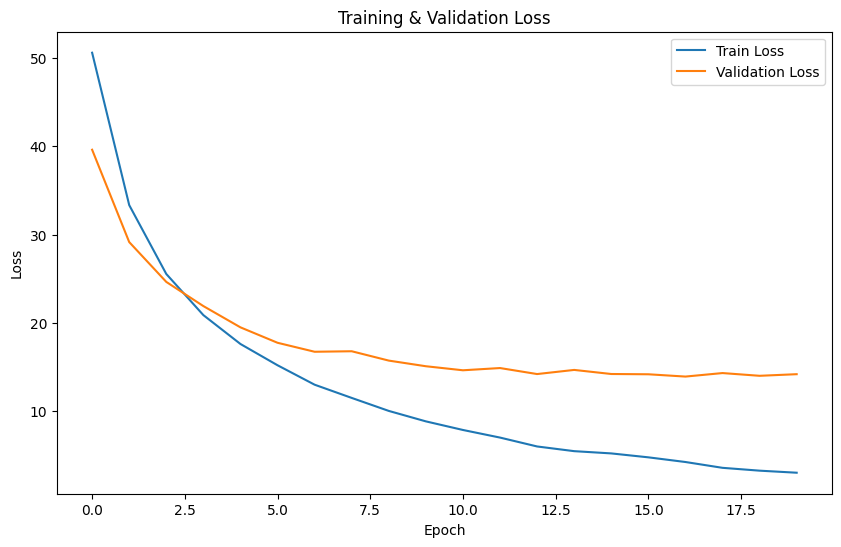

In [ ]:
import torch.optim as optim
from torch.nn.utils.rnn import pack_padded_sequence

# Hyperparameters
embed_dim = 256
decoder_dim = 512
attention_dim = 256
dropout = 0.3
vocab_size = len(token_to_index)
num_epochs = 20
learning_rate = 1e-4
weight_decay = 1e-5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model with updated parameters
model = VisiontoMathModel(
    vocab_size,
    embed_dim=embed_dim,
    decoder_dim=decoder_dim,
    attention_dim=attention_dim,
    dropout=dropout
).to(device)

# Loss function; ignore padding index (e.g., token_to_index["<PAD>"])
assert "<PAD>" in token_to_index, "Token <PAD> is missing from the vocabulary!"
criterion = nn.CrossEntropyLoss(ignore_index=token_to_index["<PAD>"])
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Training loop
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # TRAINING
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        images, _, _, encoded_latex = batch
        images = images.to(device)
        encoded_latex = encoded_latex.to(device)
        caption_lengths = (encoded_latex != token_to_index["<PAD>"]).sum(dim=1)

        preds, encoded_captions, decode_lengths, alphas, sort_ind = model(images, encoded_latex, caption_lengths)
        targets = encoded_captions[:, 1:]

        preds_pack = pack_padded_sequence(preds, decode_lengths, batch_first=True).data
        targets_pack = pack_padded_sequence(targets, decode_lengths, batch_first=True).data

        loss = criterion(preds_pack, targets_pack)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * sum(decode_lengths)

    avg_train_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # VALIDATION
    model.eval()
    val_epoch_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            images, _, _, encoded_latex = batch
            images = images.to(device)
            encoded_latex = encoded_latex.to(device)
            caption_lengths = (encoded_latex != token_to_index["<PAD>"]).sum(dim=1)

            preds, encoded_captions, decode_lengths, alphas, sort_ind = model(images, encoded_latex, caption_lengths)
            targets = encoded_captions[:, 1:]

            preds_pack = pack_padded_sequence(preds, decode_lengths, batch_first=True).data
            targets_pack = pack_padded_sequence(targets, decode_lengths, batch_first=True).data

            loss_val = criterion(preds_pack, targets_pack)
            val_epoch_loss += loss_val.item() * sum(decode_lengths)

    avg_val_loss = val_epoch_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} -- "
          f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.show()

In [ ]:
def calculate_accuracy(model, loader, device, token_to_index):
    model.eval()
    total_correct = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in loader:
            images, _, _, encoded_latex = batch
            images = images.to(device)
            encoded_latex = encoded_latex.to(device)
            caption_lengths = (encoded_latex != token_to_index["<PAD>"]).sum(dim=1)

            preds, encoded_captions, decode_lengths, alphas, sort_ind = model(images, encoded_latex, caption_lengths)
            targets = encoded_captions[:, 1:]

            preds_pack = pack_padded_sequence(preds, decode_lengths, batch_first=True).data
            targets_pack = pack_padded_sequence(targets, decode_lengths, batch_first=True).data

            # Count correct predictions
            preds_indices = preds_pack.argmax(dim=1)
            correct = (preds_indices == targets_pack).sum().item()
            total_correct += correct
            total_tokens += targets_pack.size(0)

    accuracy = total_correct / total_tokens if total_tokens > 0 else 0
    return accuracy

train_accuracy = calculate_accuracy(model, train_loader, device, token_to_index)
val_accuracy = calculate_accuracy(model, val_loader, device, token_to_index)
print(f"Train Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}")

Train Accuracy: 0.9640, Validation Accuracy: 0.8014


In [ ]:
# Generates a LaTeX caption from an image using the trained model.
def generate_caption(model, image, token_to_index, index_to_token, max_length=85):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        image = image.unsqueeze(0).to(device)
        encoder_out = model.encoder(image)
        h, c = model.decoder.init_hidden_state(encoder_out)
        current_token = torch.tensor([token_to_index["<START>"]]).to(device)

        generated_ids = []
        for t in range(max_length):
            embedding = model.decoder.embedding(current_token).unsqueeze(0)
            attention_weighted_encoding, alpha = model.decoder.attention(encoder_out, h)
            gate = model.decoder.sigmoid(model.decoder.f_beta(h))
            attention_weighted_encoding = gate * attention_weighted_encoding
            lstm_input = torch.cat([embedding.squeeze(1), attention_weighted_encoding], dim=1)
            h, c = model.decoder.decode_step(lstm_input, (h, c))
            output = model.decoder.fc(h)
            predicted = output.argmax(dim=1)
            if predicted.item() == token_to_index["<END>"]:
                break
            generated_ids.append(predicted.item())
            current_token = predicted

    # Convert indices to actual tokens
    valid_tokens = [index_to_token.get(idx, "<UNK>") for idx in generated_ids]
    # Filter out special tokens if necessary
    valid_tokens = [t for t in valid_tokens if t not in {"<START>", "<END>", "<PAD>"}]

    # Construct the final LaTeX string
    latex_str = postprocess_latex(valid_tokens)
    # Return both the string and token list
    return latex_str, valid_tokens

def postprocess_latex(tokens):
    latex = "".join(tokens)

    # Fix common errors
    replacements = {
        "^^": "^",
        "__": "_",
        "{}": "",
        "()": "",
        "[]": ""
    }

    for wrong, correct in replacements.items():
        latex = latex.replace(wrong, correct)

    # Remove unnecessary spaces
    latex = re.sub(r"\s+([_^\{])", r"\1", latex)
    latex = re.sub(r"([_^\}])\s+", r"\1", latex)

    return f"${latex}$" if not latex.startswith("$") else latex

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# Computes the BLEU score for model-generated LaTeX sequences.
def calculate_bleu(model, loader, device, token_to_index, index_to_token):
    model.eval()
    references = []
    hypotheses = []
    smoothie = SmoothingFunction().method4

    with torch.no_grad():
        for batch in loader:
            images, _, _, encoded_latex = batch
            images = images.to(device)

            # Generate predictions as token sequences
            for img in images:
                pred_latex, pred_tokens = generate_caption(model, img, token_to_index, index_to_token)
                # Append to the list
                hypotheses.append(pred_tokens)

            # Prepare reference sequences (ground truth)
            # Each reference is a list of token sequences
            for seq in encoded_latex:
                tokens = [index_to_token.get(idx, "<UNK>") for idx in seq.tolist()]
                clean_tokens = [t for t in tokens if t not in {"<START>", "<END>", "<PAD>"}]
                # NLTK BLEU expects each reference to be a list of lists
                references.append([clean_tokens])

    bleu_score = corpus_bleu(
        references,
        hypotheses,
        smoothing_function=smoothie,
        weights=(0.25, 0.25, 0.25, 0.25)  # Uniform weight for BLEU-4
    )
    return bleu_score

# Compute BLEU scores for training and validation datasets
train_bleu = calculate_bleu(model, train_loader, device, token_to_index, index_to_token)
val_bleu = calculate_bleu(model, val_loader, device, token_to_index, index_to_token)
print(f"Train BLEU: {train_bleu:.4f}, Validation BLEU: {val_bleu:.4f}")

Train BLEU: 0.9098, Validation BLEU: 0.5818


In [ ]:
def evaluate_symbol_recognition(model, loader, device, token_to_index, index_to_token):
    model.eval()
    total_correct = 0
    total_symbols = 0

    with torch.no_grad():
        for batch in loader:
            images, _, _, encoded_latex = batch
            images = images.to(device)
            encoded_latex = encoded_latex.to(device)
            caption_lengths = (encoded_latex != token_to_index["<PAD>"]).sum(dim=1)

            preds, _, decode_lengths, _, _ = model(images, encoded_latex, caption_lengths)
            preds = preds.argmax(dim=-1)  # Predicted token indices

            for i in range(len(preds)):
                pred_seq = preds[i].cpu().numpy()
                target_seq = encoded_latex[i].cpu().numpy()

                # Remove padding and special tokens (<START>, <END>)
                pred_seq = [token for token in pred_seq if token not in [token_to_index["<PAD>"], token_to_index["<START>"], token_to_index["<END>"]]]
                target_seq = [token for token in target_seq if token not in [token_to_index["<PAD>"], token_to_index["<START>"], token_to_index["<END>"]]]

                # Compare symbols
                min_length = min(len(pred_seq), len(target_seq))
                correct_symbols = sum(1 for j in range(min_length) if pred_seq[j] == target_seq[j])

                total_correct += correct_symbols
                total_symbols += len(target_seq)  # Total number of symbols in the ground truth LaTeX

    accuracy = total_correct / total_symbols if total_symbols > 0 else 0
    return accuracy

symbol_accuracy = evaluate_symbol_recognition(model, val_loader, device, token_to_index, index_to_token)
print(f"Symbol Recognition Accuracy: {symbol_accuracy:.4f}")

Symbol Recognition Accuracy: 0.1287


In [ ]:
def analyze_errors(model, loader, device, token_to_index, index_to_token, num_samples=10):
    model.eval()
    samples = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            if batch_idx >= 1:  # Check only the first batch
                break

            images, _, _, encoded_latex = batch
            images = images.to(device)

            for i in range(min(num_samples, len(images))):
                # Ground truth LaTeX sequence
                target_seq = encoded_latex[i].tolist()
                target_tokens = [index_to_token.get(idx, "<UNK>") for idx in target_seq]
                target_tokens = [t for t in target_tokens if t not in {"<START>", "<END>", "<PAD>"}]

                # Model prediction
                pred_latex, _ = generate_caption(model, images[i], token_to_index, index_to_token)

                samples.append((
                    " ".join(target_tokens),
                    pred_latex
                ))

    for idx, (target, pred) in enumerate(samples):
        print(f"Example {idx+1}:")
        print(f"Ground Truth: {target}")
        print(f"Prediction: {pred}")
        print("-" * 80)

# Run the error analysis function
analyze_errors(model, val_loader, device, token_to_index, index_to_token)

Example 1:
Ground Truth: $ n = N _ { 1 } n _ { 2 } + n _ { 1 } $
Prediction: $n=N_{1}n_{2}+n_{n}$
--------------------------------------------------------------------------------
Example 2:
Ground Truth: $ [ c , L _ { n } ] = 0 $
Prediction: $[c,L_{n}]=0$
--------------------------------------------------------------------------------
Example 3:
Ground Truth: $ a / ( b c ) $
Prediction: $a//b(t)$
--------------------------------------------------------------------------------
Example 4:
Ground Truth: $ H ( X _ { i } ) $
Prediction: $H(x_{i})$
--------------------------------------------------------------------------------
Example 5:
Ground Truth: $ 2 ^ { - 7 / 4 } $
Prediction: $2^{-1/4}$
--------------------------------------------------------------------------------
Example 6:
Ground Truth: $ T M ^ { 2 } = N ^ { 2 } $
Prediction: $TM^{2}=N^{2}$
--------------------------------------------------------------------------------
Example 7:
Ground Truth: $ M n 2 ^ { l - 1 } $
Prediction: $

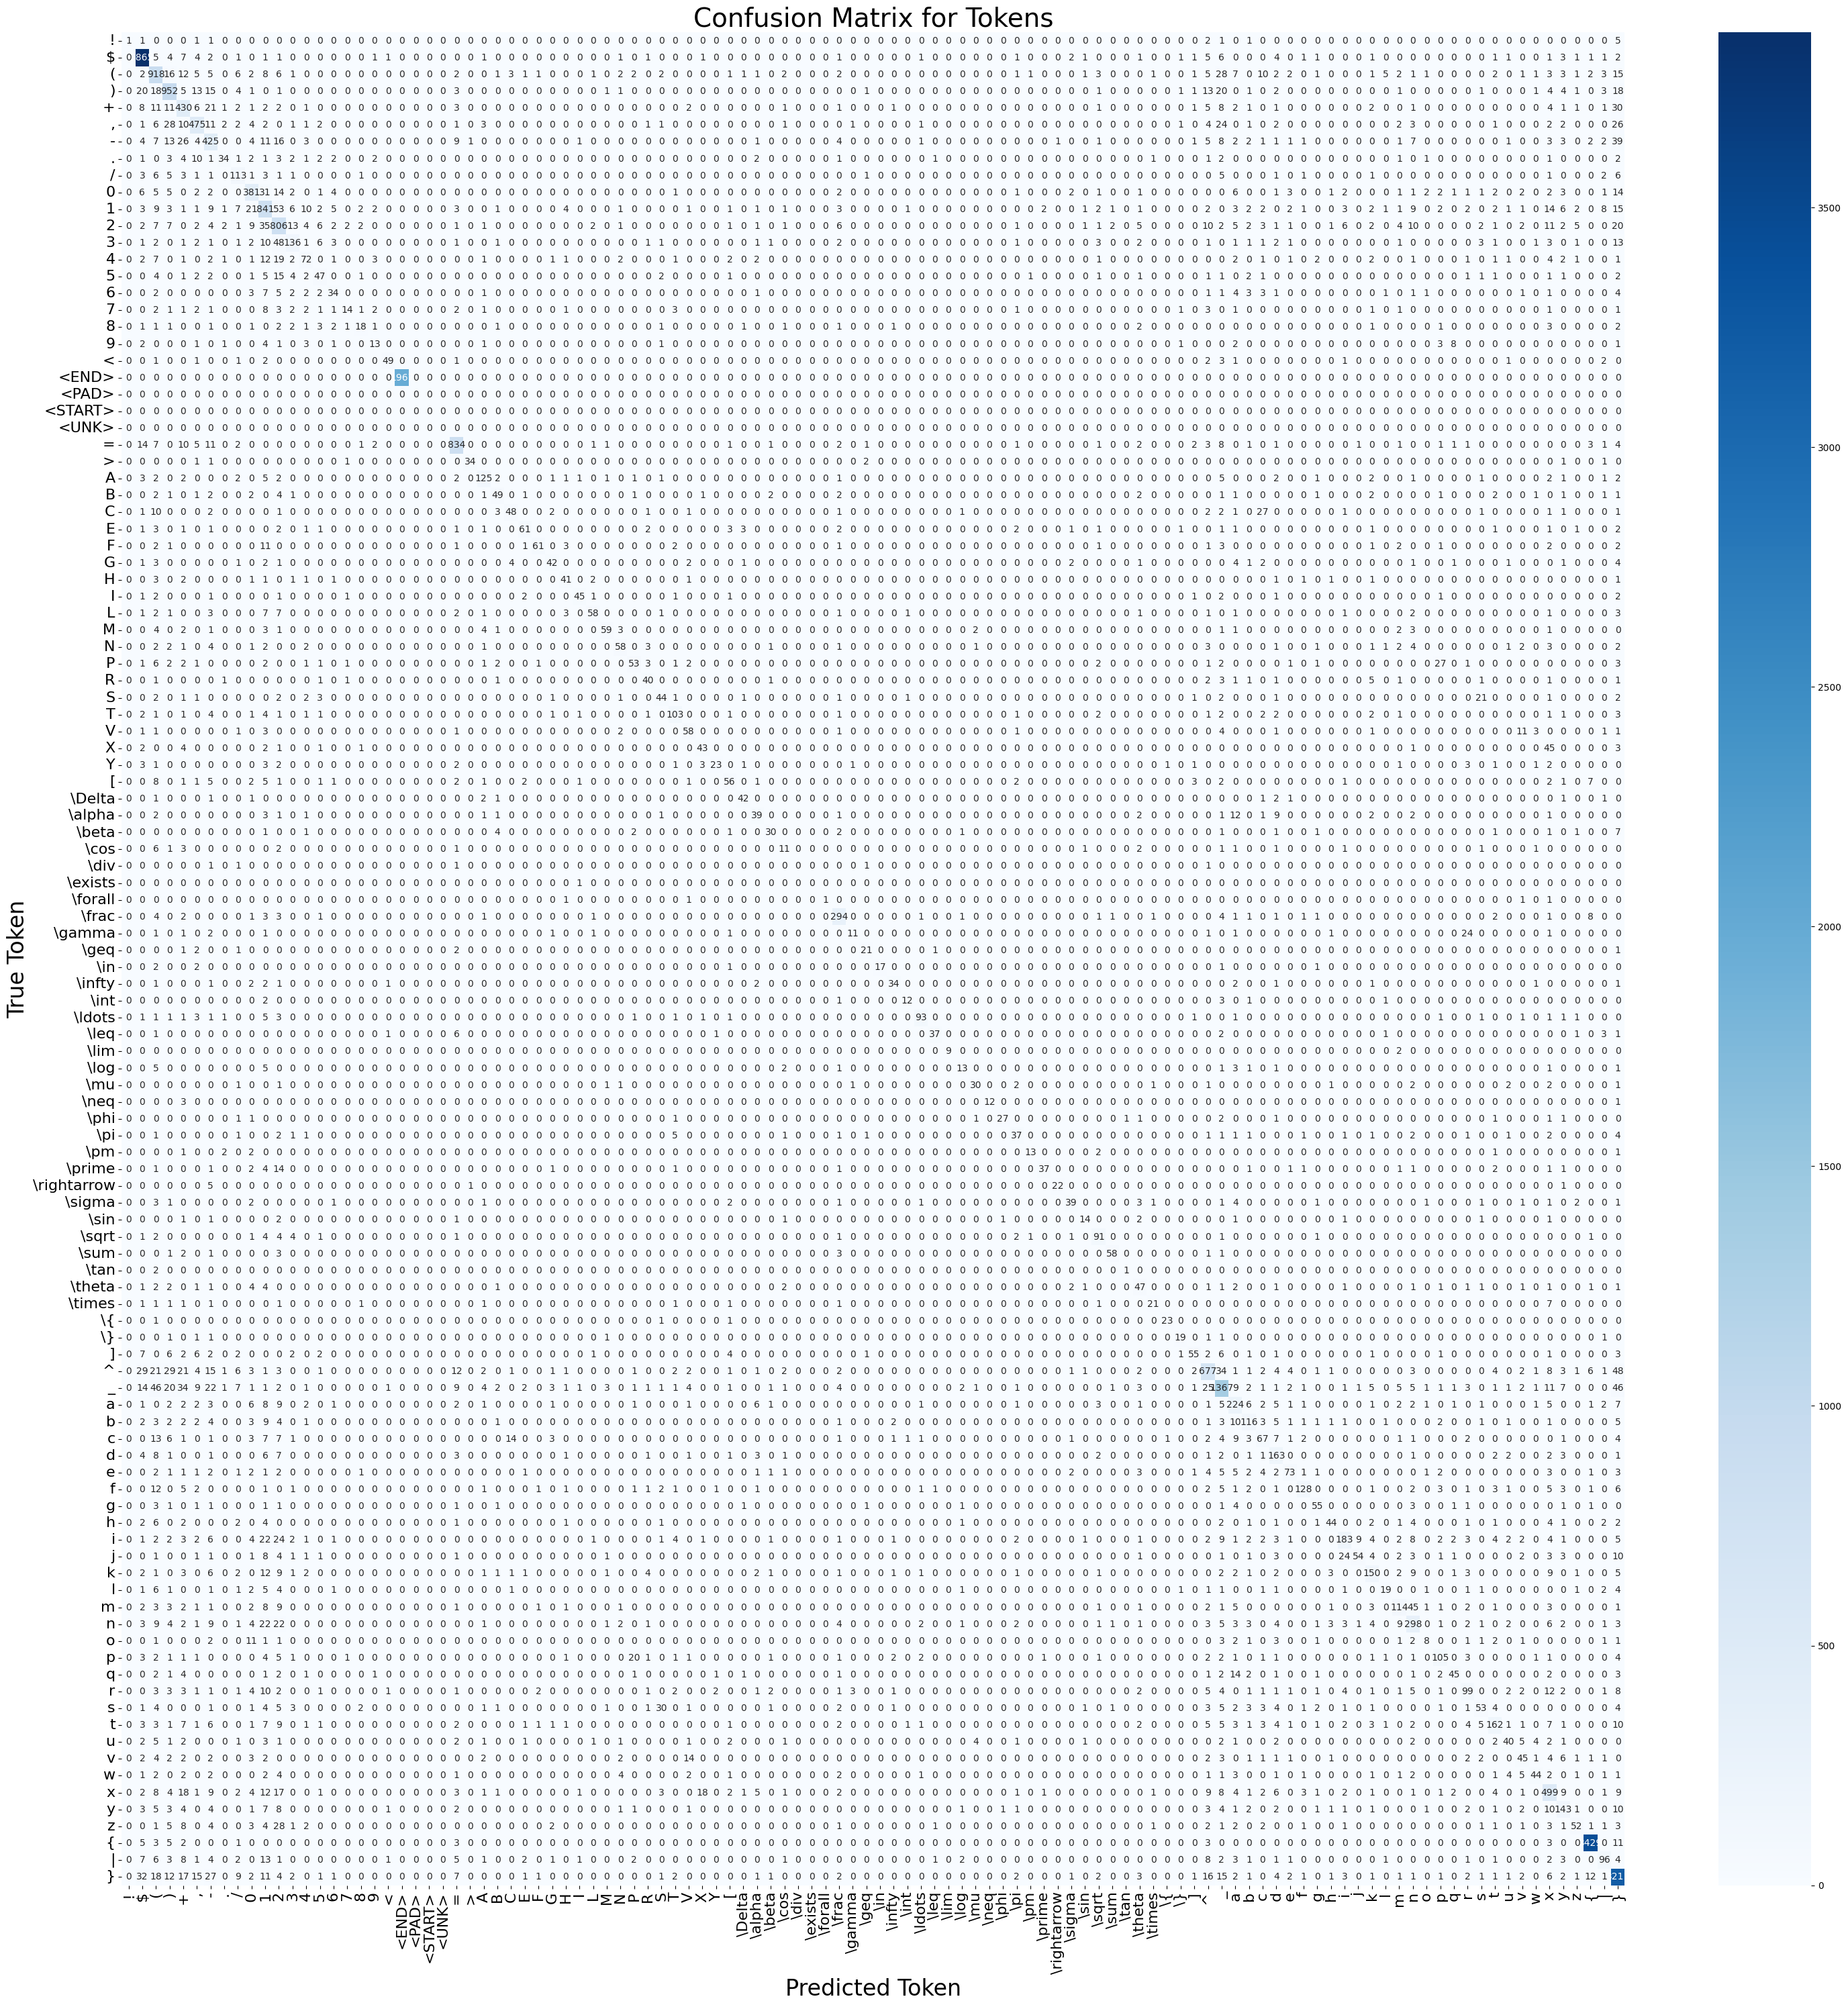

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from torch.nn.utils.rnn import pack_padded_sequence

def compute_confusion_matrix(model, loader, device, token_to_index):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            images, _, _, encoded_latex = batch
            images = images.to(device)
            encoded_latex = encoded_latex.to(device)
            caption_lengths = (encoded_latex != token_to_index["<PAD>"]).sum(dim=1)

            # Get model predictions
            preds, encoded_captions, decode_lengths, alphas, sort_ind = model(images, encoded_latex, caption_lengths)
            # Target sequence - starting from the second token (excluding <START>)
            targets = encoded_captions[:, 1:]

            # Flatten sequences using pack_padded_sequence
            preds_pack = pack_padded_sequence(preds, decode_lengths, batch_first=True).data
            targets_pack = pack_padded_sequence(targets, decode_lengths, batch_first=True).data

            # Get predicted token indices (highest probability at each step)
            preds_indices = preds_pack.argmax(dim=1).cpu().numpy()
            targets_indices = targets_pack.cpu().numpy()

            all_preds.extend(preds_indices.tolist())
            all_targets.extend(targets_indices.tolist())

    # Create a list of labels from 0 to vocab_size-1
    labels = list(range(len(token_to_index)))
    # Compute the confusion matrix
    cm = confusion_matrix(all_targets, all_preds, labels=labels)
    return cm

# Compute the confusion matrix
cm = compute_confusion_matrix(model, val_loader, device, token_to_index)

plt.figure(figsize=(30, 30))

token_labels = [index_to_token[i] for i in range(len(token_to_index))]

ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=token_labels, yticklabels=token_labels)

plt.xlabel('Predicted Token', fontsize=24)
plt.ylabel('True Token', fontsize=24)
plt.title('Confusion Matrix for Tokens', fontsize=28)

# Rotate X-axis labels 90 degrees and increase font size
plt.xticks(rotation=90, ha='center', fontsize=16)
plt.yticks(rotation=0, fontsize=16)

plt.tight_layout()
plt.show()

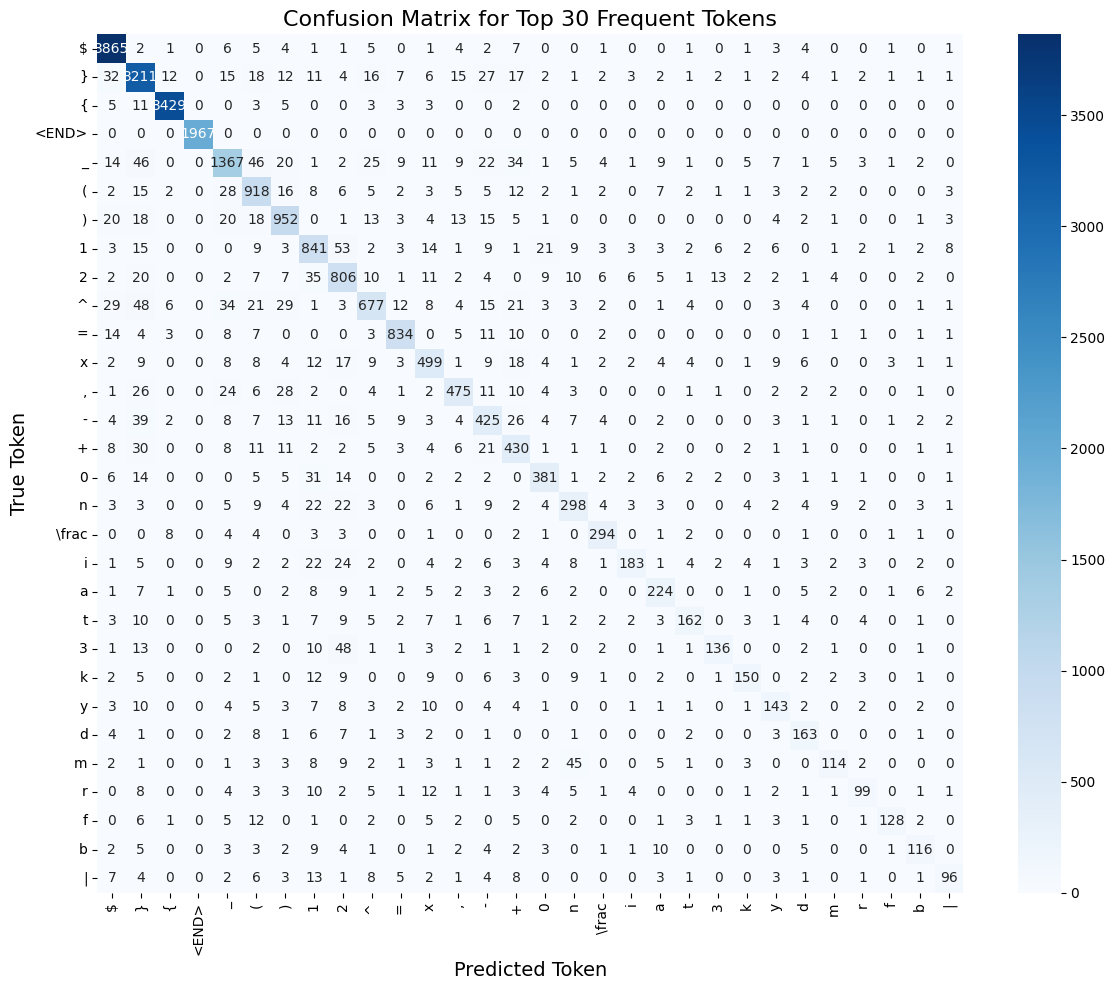

In [ ]:
import numpy as np

def get_top_token_indices(cm, top_n=30):
    # Sum along rows to count occurrences of each token in the ground truth
    token_frequencies = cm.sum(axis=1)
    # Get the indices of tokens sorted by frequency in descending order
    top_indices = np.argsort(token_frequencies)[::-1][:top_n]
    return top_indices

top_indices = get_top_token_indices(cm, top_n=30)

import seaborn as sns
import matplotlib.pyplot as plt

def plot_top_confusion_matrix(cm, top_indices, token_to_index, index_to_token):
    cm_top = cm[np.ix_(top_indices, top_indices)]

    # Get token labels for the selected indices
    top_labels = [index_to_token[i] for i in top_indices]

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_top, annot=True, fmt='d', cmap='Blues',
                xticklabels=top_labels, yticklabels=top_labels)
    plt.xlabel('Predicted Token', fontsize=14)
    plt.ylabel('True Token', fontsize=14)
    plt.title('Confusion Matrix for Top 30 Frequent Tokens', fontsize=16)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# Plot confusion matrix for the most frequent tokens
plot_top_confusion_matrix(cm, top_indices, token_to_index, index_to_token)

In [ ]:
import math

def calculate_perplexity(loss):
    return math.exp(loss)

avg_train_loss = 0.75
train_perplexity = calculate_perplexity(avg_train_loss)
print(f"Train Perplexity: {train_perplexity:.4f}")

Train Perplexity: 2.1170


In [ ]:
from sklearn.metrics import f1_score

def calculate_token_f1(model, loader, device, token_to_index):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            images, _, _, encoded_latex = batch
            images = images.to(device)
            encoded_latex = encoded_latex.to(device)
            caption_lengths = (encoded_latex != token_to_index["<PAD>"]).sum(dim=1)

            preds, encoded_captions, decode_lengths, alphas, sort_ind = model(images, encoded_latex, caption_lengths)
            targets = encoded_captions[:, 1:]

            preds_pack = pack_padded_sequence(preds, decode_lengths, batch_first=True).data
            targets_pack = pack_padded_sequence(targets, decode_lengths, batch_first=True).data

            preds_indices = preds_pack.argmax(dim=1).cpu().numpy()
            targets_indices = targets_pack.cpu().numpy()

            all_preds.extend(preds_indices.tolist())
            all_targets.extend(targets_indices.tolist())

    # Compute micro-averaged F1-score
    f1 = f1_score(all_targets, all_preds, average='micro')
    return f1

f1_token = calculate_token_f1(model, val_loader, device, token_to_index)
print(f"Validation Token-level F1-Score: {f1_token:.4f}")

Validation Token-level F1-Score: 0.8014


In [ ]:
import torch
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
import numpy as np

def generate_caption_from_image(model, image_tensor, token_to_index, index_to_token, max_length=85):
    model.eval()
    device = next(model.parameters()).device

    # Convert numpy array to torch.Tensor if needed
    if isinstance(image_tensor, np.ndarray):
        image_tensor = torch.from_numpy(image_tensor)
        if image_tensor.dtype == torch.uint8:
            image_tensor = image_tensor.float() / 255.0

    # If the image has shape (256, 256) (single-channel), add a channel dimension
    if image_tensor.dim() == 2:
        image_tensor = image_tensor.unsqueeze(0)  # Now (1, 256, 256)

    # If the image has 1 channel, replicate it to 3 channels
    if image_tensor.shape[0] == 1:
        image_tensor = image_tensor.repeat(3, 1, 1)  # Now (3, 256, 256)

    # Validate input dimensions
    if image_tensor.shape != torch.Size([3, 256, 256]):
        raise ValueError(f"Expected image_tensor to have shape (3, 256, 256), but got {image_tensor.shape}")

    with torch.no_grad():
        # Add batch dimension: (1, 3, 256, 256)
        image = image_tensor.unsqueeze(0).to(device)
        encoder_out = model.encoder(image)  # (1, num_pixels, encoder_dim)
        h, c = model.decoder.init_hidden_state(encoder_out)
        current_token = torch.tensor([token_to_index["<START>"]]).to(device)

        generated_ids = []
        for t in range(max_length):
            embedding = model.decoder.embedding(current_token).unsqueeze(0)  # (1, 1, embed_dim)
            attention_weighted_encoding, alpha = model.decoder.attention(encoder_out, h)
            gate = model.decoder.sigmoid(model.decoder.f_beta(h))
            attention_weighted_encoding = gate * attention_weighted_encoding
            lstm_input = torch.cat([embedding.squeeze(1), attention_weighted_encoding], dim=1)
            h, c = model.decoder.decode_step(lstm_input, (h, c))
            output = model.decoder.fc(h)  # (1, vocab_size)
            predicted = output.argmax(dim=1)
            if predicted.item() == token_to_index["<END>"]:
                break
            generated_ids.append(predicted.item())
            current_token = predicted

    generated_tokens = [index_to_token.get(idx, "<UNK>") for idx in generated_ids]
    # Filter out special tokens
    generated_tokens = [t for t in generated_tokens if t not in {"<START>", "<END>", "<PAD>"}]
    latex_str = postprocess_latex(generated_tokens)
    return latex_str, generated_tokens

In [ ]:
! pip install Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.7/162.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 89.3 MB/s eta 0:00:00


In [ ]:
import Levenshtein

def calculate_average_levenshtein(model, loader, device, token_to_index, index_to_token):
    model.eval()
    distances = []

    with torch.no_grad():
        for batch in loader:
            images, _, _, encoded_latex = batch
            images = images.to(device)

            for i in range(images.size(0)):
                # Generate prediction
                pred_latex, _ = generate_caption_from_image(model, images[i], token_to_index, index_to_token)

                # Convert ground truth sequence to LaTeX string
                target_tokens = [index_to_token.get(idx.item(), "<UNK>") for idx in encoded_latex[i]]
                # Filter out special tokens
                target_tokens = [t for t in target_tokens if t not in {"<START>", "<END>", "<PAD>"}]
                target_latex = " ".join(target_tokens)

                # Compute Levenshtein distance
                distance = Levenshtein.distance(pred_latex, target_latex)
                distances.append(distance)

    avg_distance = sum(distances) / len(distances) if distances else 0
    return avg_distance

avg_levenshtein = calculate_average_levenshtein(model, val_loader, device, token_to_index, index_to_token)
print(f"Average Levenshtein Distance on Validation: {avg_levenshtein:.4f}")

Average Levenshtein Distance on Validation: 19.5206


In [ ]:
import Levenshtein
import torch
from torch.nn.utils.rnn import pack_padded_sequence

def calculate_cer(pred_text, true_text):
    # Compute the Levenshtein distance between the two strings
    edit_distance = Levenshtein.distance(pred_text, true_text)
    # CER = edit_distance / length of the ground truth text
    cer = edit_distance / len(true_text) if len(true_text) > 0 else 0
    return cer

def calculate_average_cer(model, loader, device, token_to_index, index_to_token):
    model.eval()
    total_cer = 0.0
    count = 0

    with torch.no_grad():
        for batch in loader:
            images, _, _, encoded_latex = batch
            images = images.to(device)

            # Iterate through each image in the batch
            for i in range(images.size(0)):
                # Generate LaTeX sequence and tokens
                pred_latex, _ = generate_caption(model, images[i], token_to_index, index_to_token)

                # Convert ground truth sequence indices to tokens
                target_tokens = [index_to_token.get(idx.item(), "<UNK>") for idx in encoded_latex[i]]
                # Filter out special tokens
                target_tokens = [t for t in target_tokens if t not in {"<START>", "<END>", "<PAD>"}]
                # Join tokens into a string (without spaces, as characters are sequential)
                true_text = "".join(target_tokens)

                # Compute CER for this example
                cer_value = calculate_cer(pred_latex, true_text)
                total_cer += cer_value
                count += 1

    avg_cer = total_cer / count if count > 0 else 0
    return avg_cer

# Example function call for a dataset (e.g., validation set)
avg_cer = calculate_average_cer(model, val_loader, device, token_to_index, index_to_token)
print(f"Average CER: {avg_cer:.4f}")

Average CER: 0.2243


Generated tokens: ['$', '[', 'c', ',', 'L', '_', '{', 'n', '}', ']', '=', '0', '$']


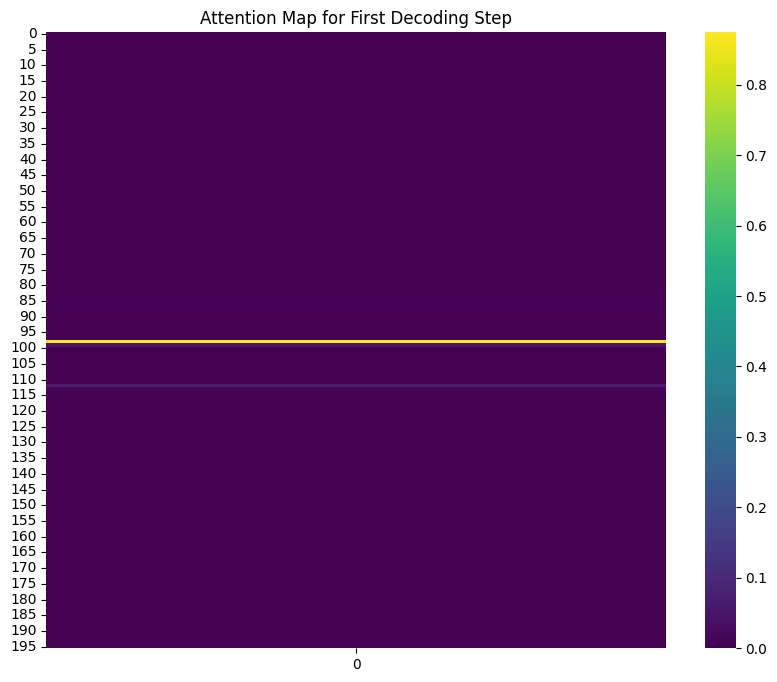

In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_attention(model, image, token_to_index, index_to_token, max_length=85):
    model.eval()
    device = next(model.parameters()).device
    image = image.to(device).unsqueeze(0)  # Add batch dimension
    encoder_out = model.encoder(image)
    h, c = model.decoder.init_hidden_state(encoder_out)
    current_token = torch.tensor([token_to_index["<START>"]]).to(device)

    attention_maps = []
    generated_tokens = []

    with torch.no_grad():
        for t in range(max_length):
            embedding = model.decoder.embedding(current_token).unsqueeze(0)
            attention_weighted_encoding, alpha = model.decoder.attention(encoder_out, h)
            # Convert alpha to numpy for visualization
            attn_np = alpha.cpu().numpy()
            # If alpha has shape (1, num_pixels), remove batch dimension
            if attn_np.ndim == 2:
                attn_np = attn_np.squeeze(0)  # Now (num_pixels,)
            # Reshape into a 2D array (num_pixels, 1) for heatmap visualization
            attn_np = attn_np.reshape(-1, 1)
            attention_maps.append(attn_np)

            gate = model.decoder.sigmoid(model.decoder.f_beta(h))
            attention_weighted_encoding = gate * attention_weighted_encoding
            lstm_input = torch.cat([embedding.squeeze(1), attention_weighted_encoding], dim=1)
            h, c = model.decoder.decode_step(lstm_input, (h, c))
            output = model.decoder.fc(h)
            predicted = output.argmax(dim=1)
            if predicted.item() == token_to_index["<END>"]:
                break
            generated_tokens.append(index_to_token.get(predicted.item(), "<UNK>"))
            current_token = predicted

    return generated_tokens, attention_maps

# Example: Visualizing attention for a single image from the validation set
sample_image, _, _, _ = next(iter(val_loader))
sample_image = sample_image[1]  # Select the first image
gen_tokens, attn_maps = visualize_attention(model, sample_image, token_to_index, index_to_token)

print("Generated tokens:", gen_tokens)

# Visualize the attention map for the first decoding step
plt.figure(figsize=(10, 8))
sns.heatmap(attn_maps[0], cmap="viridis")
plt.title("Attention Map for First Decoding Step")
plt.show()

## Model Testing

Example 1: Image shape after transformation: torch.Size([3, 256, 256])
Example 1: Generated LaTeX string: $A=\sqrt{\sqrt{++a+a^{2}}^{2}$


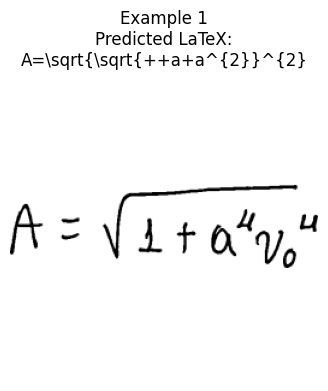

Example 2: Image shape after transformation: torch.Size([3, 256, 256])
Example 2: Generated LaTeX string: $(a_{0},a_{0}=(u_{1}u_{2}(u_{1},u_{2})}$


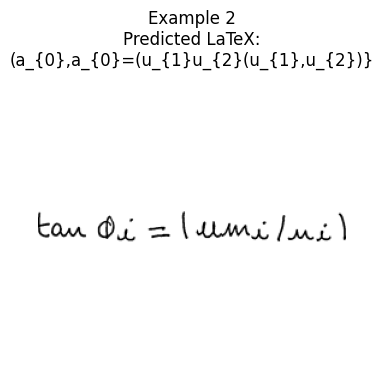

Example 3: Image shape after transformation: torch.Size([3, 256, 256])
Example 3: Generated LaTeX string: $-X<y$


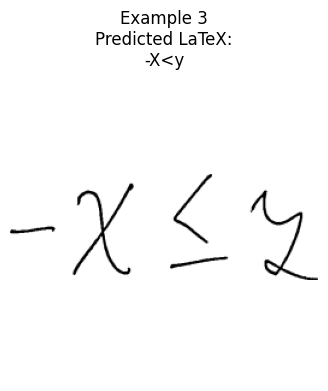

Example 4: Image shape after transformation: torch.Size([3, 256, 256])
Example 4: Generated LaTeX string: $\frac{1}{2}s_{2}(v)}(x)=0$


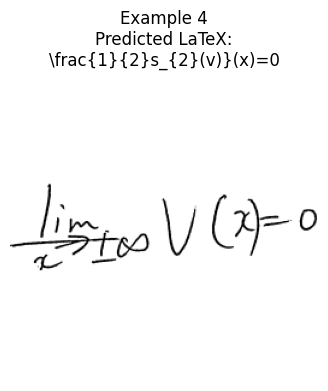

Example 5: Image shape after transformation: torch.Size([3, 256, 256])
Example 5: Generated LaTeX string: $Sdz$


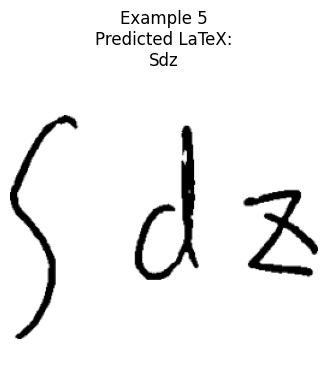

Predicted LaTeX for the first 5 examples:
Example 1: $A=\sqrt{\sqrt{++a+a^{2}}^{2}$
Example 2: $(a_{0},a_{0}=(u_{1}u_{2}(u_{1},u_{2})}$
Example 3: $-X<y$
Example 4: $\frac{1}{2}s_{2}(v)}(x)=0$
Example 5: $Sdz$


In [ ]:
def postprocess_latex(tokens):
    latex = "".join(tokens)
    # Replace known incorrect tokens
    latex = latex.replace(r'\timesxm', r'\times')

    # Basic replacements to remove duplicate symbols
    replacements = {
        "^^": "^",
        "__": "_",
        "{}": "",
        "()": "",
        "[]": ""
    }
    for wrong, correct in replacements.items():
        latex = latex.replace(wrong, correct)
    latex = " ".join(latex.split())
    if not latex.startswith("$"):
        latex = f"${latex}$"
    return latex


def test_first_images(model, preprocessed_data, token_to_index, index_to_token, max_length=85, num_samples=5):
    if not preprocessed_data:
        print("Preprocessed data is empty!")
        return []

    predicted_latex_list = []

    for i in range(min(num_samples, len(preprocessed_data))):
        item = preprocessed_data[i]
        image_tensor = item.get('preprocessed', None)
        if image_tensor is None:
            print(f"Item at index {i} does not contain the key 'preprocessed'. Skipping.")
            continue

        # Convert numpy.ndarray to torch.Tensor if necessary
        if isinstance(image_tensor, np.ndarray):
            image_tensor = torch.from_numpy(image_tensor)
            if image_tensor.dtype == torch.uint8:
                image_tensor = image_tensor.float() / 255.0

        # If the image shape is (256,256), add channel dimension and repeat to 3 channels
        if image_tensor.dim() == 2:
            image_tensor = image_tensor.unsqueeze(0)
        if image_tensor.shape[0] == 1:
            image_tensor = image_tensor.repeat(3, 1, 1)

        print(f"Example {i+1}: Image shape after transformation: {image_tensor.shape}")

        # Generate a prediction for the given image
        latex_str, generated_tokens = generate_caption_from_image(
            model, image_tensor, token_to_index, index_to_token, max_length=max_length
        )
        print(f"Example {i+1}: Generated LaTeX string: {latex_str}")
        predicted_latex_list.append(latex_str)

        # Convert the image tensor to a PIL image for display
        image_pil = to_pil_image(image_tensor.cpu())
        plt.figure(figsize=(5, 4))
        plt.imshow(image_pil)
        plt.axis("off")
        # Display the string without "$" symbols to avoid MathText interpretation
        display_str = latex_str.replace("$", "")
        plt.title(f"Example {i+1}\nPredicted LaTeX:\n{display_str}", fontsize=12)
        plt.show()

    return predicted_latex_list


# Function call for the first 5 test samples
predicted_latex_list = test_first_images(
    model=model,
    preprocessed_data=preprocessed_test_data,
    token_to_index=token_to_index,
    index_to_token=index_to_token,
    max_length=85,
    num_samples=5
)

print("Predicted LaTeX for the first 5 examples:")
for i, latex in enumerate(predicted_latex_list):
    print(f"Example {i+1}: {latex}")

#Baseline model

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20 -- Train Loss: 55.2012, Val Loss: 44.0710
Epoch 2/20 -- Train Loss: 38.6375, Val Loss: 35.9950
Epoch 3/20 -- Train Loss: 32.8024, Val Loss: 32.0483
Epoch 4/20 -- Train Loss: 29.1757, Val Loss: 29.3374
Epoch 5/20 -- Train Loss: 26.5760, Val Loss: 27.6106
Epoch 6/20 -- Train Loss: 24.4960, Val Loss: 26.2280
Epoch 7/20 -- Train Loss: 22.7462, Val Loss: 25.3687
Epoch 8/20 -- Train Loss: 21.2656, Val Loss: 24.5428
Epoch 9/20 -- Train Loss: 19.9766, Val Loss: 23.6900
Epoch 10/20 -- Train Loss: 18.8068, Val Loss: 23.4055
Epoch 11/20 -- Train Loss: 17.7607, Val Loss: 22.7672
Epoch 12/20 -- Train Loss: 16.9045, Val Loss: 22.4156
Epoch 13/20 -- Train Loss: 15.9996, Val Loss: 22.4720
Epoch 14/20 -- Train Loss: 15.2286, Val Loss: 22.0049
Epoch 15/20 -- Train Loss: 14.4757, Val Loss: 21.7377
Epoch 16/20 -- Train Loss: 13.8627, Val Loss: 21.5617
Epoch 17/20 -- Train Loss: 13.1805, Val Loss: 21.2000
Epoch 18/20 -- Train Loss: 12.7216, Val Loss: 21.1793
Epoch 19/20 -- Train Loss: 12.1957, V

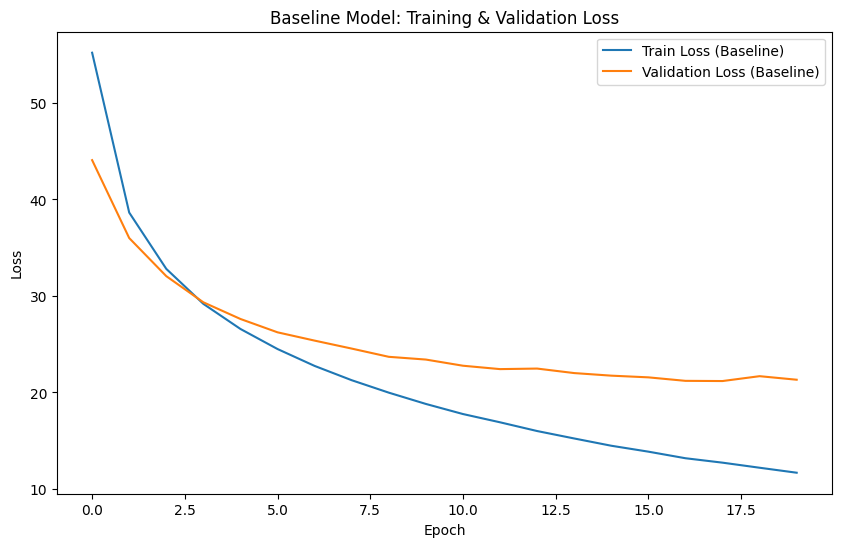

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.nn.utils.rnn import pack_padded_sequence
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. CNN Encoder (simple, with spatial feature averaging)
class CNNEncoderBaseline(nn.Module):
    def __init__(self, encoded_image_size=14):
        super(CNNEncoderBaseline, self).__init__()
        self.enc_image_size = encoded_image_size
        resnet = models.resnet18(pretrained=True)
        # Remove the last layers (avgpool and fc)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        batch_size, encoder_dim, H, W = features.size()
        # Average over spatial dimensions
        features = features.view(batch_size, encoder_dim, -1).mean(dim=2)
        return features

# 2. Baseline Decoder based on LSTM (no attention)
class BaselineDecoder(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size, dropout=0.5):
        super(BaselineDecoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

        self.init_weights()

    def init_weights(self):
        self.embedding.weight.data.uniform_(-0.1, 0.1)
        self.fc.bias.data.fill_(0)
        self.fc.weight.data.uniform_(-0.1, 0.1)

    def forward(self, features, encoded_captions, caption_lengths):
        # Get embeddings for tokens
        embeddings = self.embedding(encoded_captions)  # (batch, max_caption_length, embed_dim)
        embeddings = self.dropout(embeddings)

        # Use encoder features as initial hidden state for LSTM
        h0 = features.unsqueeze(0)  # (1, batch, encoder_dim)
        c0 = torch.zeros_like(h0)     # (1, batch, encoder_dim)

        # Pack the sequences (moving caption_lengths to CPU)
        packed_embeddings = nn.utils.rnn.pack_padded_sequence(
            embeddings, caption_lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        # Pass through LSTM
        packed_outputs, _ = self.lstm(packed_embeddings, (h0, c0))
        # Unpack LSTM output
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_outputs, batch_first=True)

        # Apply fc to get probabilities for the vocabulary
        outputs = self.fc(outputs)
        return outputs

# 3. Baseline Model combining encoder and decoder
class BaselineModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, encoded_image_size=14, dropout=0.5):
        super(BaselineModel, self).__init__()
        self.encoder = CNNEncoderBaseline(encoded_image_size=encoded_image_size)
        self.decoder = BaselineDecoder(embed_dim, hidden_dim, vocab_size, dropout=dropout)

    def forward(self, images, encoded_captions, caption_lengths):
        features = self.encoder(images)
        outputs = self.decoder(features, encoded_captions, caption_lengths)
        return outputs

# Initialization of the baseline model
embed_dim = 256
hidden_dim = 512
vocab_size = len(token_to_index)
dropout = 0.3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model = BaselineModel(vocab_size, embed_dim, hidden_dim, encoded_image_size=14, dropout=dropout).to(device)

# Define loss function and optimizer
criterion_baseline = nn.CrossEntropyLoss(ignore_index=token_to_index["<PAD>"])
optimizer_baseline = optim.Adam(baseline_model.parameters(), lr=1e-4, weight_decay=1e-5)

# Training loop for baseline model
num_epochs_baseline = 20
train_losses_baseline = []
val_losses_baseline = []

for epoch in range(num_epochs_baseline):
    # TRAINING
    baseline_model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        # Batch structure: (images, bounding_boxes, relations, encoded_latex)
        images, _, _, encoded_latex = batch
        images = images.to(device)
        encoded_latex = encoded_latex.to(device)

        # Calculate sequence lengths (excluding padding)
        caption_lengths = (encoded_latex != token_to_index["<PAD>"]).sum(dim=1)

        # Forward pass through the model
        outputs = baseline_model(images, encoded_latex, caption_lengths)
        # outputs shape: (batch, max_caption_length, vocab_size)
        targets = encoded_latex[:, 1:]

        # Flatten predictions and targets, moving lengths to CPU and enforcing enforce_sorted=False
        outputs_pack = pack_padded_sequence(outputs, (caption_lengths - 1).cpu(), batch_first=True, enforce_sorted=False).data
        targets_pack = pack_padded_sequence(targets, (caption_lengths - 1).cpu(), batch_first=True, enforce_sorted=False).data

        loss = criterion_baseline(outputs_pack, targets_pack)
        optimizer_baseline.zero_grad()
        loss.backward()
        optimizer_baseline.step()

        epoch_loss += loss.item() * (caption_lengths - 1).sum().item()

    avg_train_loss = epoch_loss / len(train_loader.dataset)
    train_losses_baseline.append(avg_train_loss)

    # VALIDATION
    baseline_model.eval()
    val_epoch_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            images, _, _, encoded_latex = batch
            images = images.to(device)
            encoded_latex = encoded_latex.to(device)
            caption_lengths = (encoded_latex != token_to_index["<PAD>"]).sum(dim=1)

            outputs = baseline_model(images, encoded_latex, caption_lengths)
            targets = encoded_latex[:, 1:]

            outputs_pack = pack_padded_sequence(outputs, (caption_lengths - 1).cpu(), batch_first=True, enforce_sorted=False).data
            targets_pack = pack_padded_sequence(targets, (caption_lengths - 1).cpu(), batch_first=True, enforce_sorted=False).data

            loss_val = criterion_baseline(outputs_pack, targets_pack)
            val_epoch_loss += loss_val.item() * (caption_lengths - 1).sum().item()

    avg_val_loss = val_epoch_loss / len(val_loader.dataset)
    val_losses_baseline.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs_baseline} -- Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

# Visualizing the training and validation loss for the baseline model
plt.figure(figsize=(10,6))
plt.plot(train_losses_baseline, label='Train Loss (Baseline)')
plt.plot(val_losses_baseline, label='Validation Loss (Baseline)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Baseline Model: Training & Validation Loss')
plt.show()

In [ ]:
import torch
from torch.nn.utils.rnn import pack_padded_sequence
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import Levenshtein
import math

# Function to generate a sequence for the baseline model
def generate_caption_baseline(model, image, token_to_index, index_to_token, max_length=85):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        # Prepare image: expand batch size
        image = image.unsqueeze(0).to(device)
        # Extract features via encoder
        features = model.encoder(image)  # (1, encoder_dim)

        # Initialize the LSTM decoder using features as the initial hidden state.
        # Force use of <START> token.
        current_token = torch.tensor([[token_to_index["<START>"]]]).to(device)  # (1,1)

        generated_ids = []
        # Initialize LSTM states: use features as h0, and set c0 to zeros
        h0 = features.unsqueeze(0)  # (1, 1, encoder_dim)
        c0 = torch.zeros_like(h0)     # (1, 1, encoder_dim)

        hidden, cell = h0, c0
        for t in range(max_length):
            emb = model.decoder.embedding(current_token)  # (1,1,embed_dim)
            out, (hidden, cell) = model.decoder.lstm(emb, (hidden, cell))  # out: (1,1,hidden_dim)
            logits = model.decoder.fc(out.squeeze(1))  # (1, vocab_size)
            predicted = logits.argmax(dim=1)  # (1,)
            if predicted.item() == token_to_index["<END>"]:
                break
            generated_ids.append(predicted.item())
            current_token = predicted.unsqueeze(0)  # (1,1) for the next step

        # Convert indices to tokens
        generated_tokens = [index_to_token.get(idx, "<UNK>") for idx in generated_ids]
        # Filter out special tokens
        generated_tokens = [t for t in generated_tokens if t not in {"<START>", "<END>", "<PAD>"}]
        # Assemble final LaTeX string
        latex_str = "".join(generated_tokens)
        if not latex_str.startswith("$"):
            latex_str = "$" + latex_str + "$"
    return latex_str, generated_tokens

# 1. Accuracy for the baseline model
def calculate_accuracy_baseline(model, loader, device, token_to_index):
    model.eval()
    total_correct = 0
    total_tokens = 0
    with torch.no_grad():
        for batch in loader:
            images, _, _, encoded_latex = batch
            images = images.to(device)
            encoded_latex = encoded_latex.to(device)
            caption_lengths = (encoded_latex != token_to_index["<PAD>"]).sum(dim=1)

            outputs = model(images, encoded_latex, caption_lengths)
            targets = encoded_latex[:, 1:]

            outputs_pack = pack_padded_sequence(outputs, (caption_lengths - 1).cpu(),
                                                 batch_first=True, enforce_sorted=False).data
            targets_pack = pack_padded_sequence(targets, (caption_lengths - 1).cpu(),
                                                 batch_first=True, enforce_sorted=False).data
            preds = outputs_pack.argmax(dim=1)
            total_correct += (preds == targets_pack).sum().item()
            total_tokens += targets_pack.size(0)
    return total_correct / total_tokens if total_tokens > 0 else 0

# 2. BLEU score for the baseline model
def calculate_bleu_baseline(model, loader, device, token_to_index, index_to_token):
    model.eval()
    references = []
    hypotheses = []
    smoothie = SmoothingFunction().method4
    with torch.no_grad():
        for batch in loader:
            images, _, _, encoded_latex = batch
            images = images.to(device)
            # Generate predictions for each image in the batch
            for img in images:
                _, pred_tokens = generate_caption_baseline(model, img, token_to_index, index_to_token)
                hypotheses.append(pred_tokens)
            # Prepare reference sequences
            for seq in encoded_latex:
                tokens = [index_to_token.get(idx.item(), "<UNK>") for idx in seq]
                clean_tokens = [t for t in tokens if t not in {"<START>", "<END>", "<PAD>"}]
                references.append([clean_tokens])
    bleu_score = corpus_bleu(references, hypotheses, smoothing_function=smoothie,
                              weights=(0.25, 0.25, 0.25, 0.25))
    return bleu_score

# 3. Character Error Rate (CER) for the baseline model
def calculate_cer_baseline(model, loader, device, token_to_index, index_to_token):
    model.eval()
    total_cer = 0.0
    count = 0
    with torch.no_grad():
        for batch in loader:
            images, _, _, encoded_latex = batch
            images = images.to(device)
            for i in range(images.size(0)):
                pred_latex, _ = generate_caption_baseline(model, images[i], token_to_index, index_to_token)
                target_tokens = [index_to_token.get(idx.item(), "<UNK>") for idx in encoded_latex[i]]
                target_tokens = [t for t in target_tokens if t not in {"<START>", "<END>", "<PAD>"}]
                true_text = "".join(target_tokens)
                if len(true_text) == 0:
                    continue
                edit_distance = Levenshtein.distance(pred_latex, true_text)
                cer = edit_distance / len(true_text)
                total_cer += cer
                count += 1
    return total_cer / count if count > 0 else 0

# 4. Perplexity: computed as the exponential of the average loss (on the train or validation set)
def calculate_perplexity_baseline(avg_loss):
    return math.exp(avg_loss)

acc_baseline = calculate_accuracy_baseline(baseline_model, val_loader, device, token_to_index)
bleu_baseline = calculate_bleu_baseline(baseline_model, val_loader, device, token_to_index, index_to_token)
cer_baseline = calculate_cer_baseline(baseline_model, val_loader, device, token_to_index, index_to_token)

print(f"Baseline Model Accuracy: {acc_baseline:.4f}")
print(f"Baseline Model BLEU: {bleu_baseline:.4f}")
print(f"Baseline Model CER: {cer_baseline:.4f}")

avg_loss_baseline = sum(train_losses_baseline) / len(train_losses_baseline)
perplexity_baseline = calculate_perplexity_baseline(avg_loss_baseline)
print(f"Baseline Model Perplexity: {perplexity_baseline:.4f}")

Baseline Model Accuracy: 0.6976
Baseline Model BLEU: 0.3761
Baseline Model CER: 0.4004
Baseline Model Perplexity: 2615275209.3462


# Hyperparameter tuning

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.4/383.4 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.9 MB/s eta 0:00:00


In [ ]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pack_padded_sequence

def train_one_epoch(model, optimizer, criterion, train_loader, device):
    model.train()
    epoch_loss = 0.0
    for images, _, _, encoded_latex in train_loader:
        images = images.to(device)
        encoded_latex = encoded_latex.to(device)

        optimizer.zero_grad()
        predictions, target_captions, decode_lengths, alphas, sort_ind = model(images, encoded_latex, (encoded_latex != token_to_index["<PAD>"]).sum(dim=1))
        targets = target_captions[:, 1:]

        predictions_packed = pack_padded_sequence(predictions, decode_lengths, batch_first=True).data
        targets_packed = pack_padded_sequence(targets, decode_lengths, batch_first=True).data
        loss = criterion(predictions_packed, targets_packed)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * images.size(0)

    return epoch_loss / len(train_loader.dataset)

def validate(model, criterion, val_loader, device):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _, _, encoded_latex in val_loader:
            images = images.to(device)
            encoded_latex = encoded_latex.to(device)
            predictions, target_captions, decode_lengths, alphas, sort_ind = model(images, encoded_latex, (encoded_latex != token_to_index["<PAD>"]).sum(dim=1))
            targets = target_captions[:, 1:]
            predictions_packed = pack_padded_sequence(predictions, decode_lengths, batch_first=True).data
            targets_packed = pack_padded_sequence(targets, decode_lengths, batch_first=True).data
            loss = criterion(predictions_packed, targets_packed)
            val_loss += loss.item() * images.size(0)
    return val_loss / len(val_loader.dataset)

def objective(trial):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Optimizable hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    dropout = trial.suggest_categorical("dropout", [0.3, 0.5])
    weight_decay = trial.suggest_categorical("weight_decay", [0, 1e-5])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    num_epochs = trial.suggest_int("num_epochs", 5, 10)

    # Creating the model with new parameters
    model = VisiontoMathModel(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        decoder_dim=decoder_dim,
        attention_dim=attention_dim,
        dropout=dropout
    ).to(device)

    # Choosing the optimizer
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Loss function
    criterion = nn.CrossEntropyLoss(ignore_index=token_to_index["<PAD>"])

    best_val_loss = float('inf')
    no_improvement = 0

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, optimizer, criterion, train_loader, device)
        val_loss = validate(model, criterion, val_loader, device)

        trial.report(val_loss, epoch)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improvement = 0
        else:
            no_improvement += 1

        # Stop if there is no improvement for 3 consecutive epochs
        if no_improvement >= 3:
            raise optuna.exceptions.TrialPruned()

    return best_val_loss

# Running Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("Best trial:")
print("  Value (Best Validation Loss):", study.best_trial.value)
print("  Best Params:", study.best_trial.params)

[I 2025-02-07 13:03:41,056] A new study created in memory with name: no-name-7989bb22-9534-449a-8d4f-c4913372ae94
[I 2025-02-07 13:08:56,505] Trial 0 finished with value: 3.5310167554798135 and parameters: {'lr': 0.000602497769200806, 'dropout': 0.5, 'weight_decay': 1e-05, 'optimizer': 'SGD', 'num_epochs': 7}. Best is trial 0 with value: 3.5310167554798135.
[I 2025-02-07 13:15:41,442] Trial 1 finished with value: 3.5329464949747 and parameters: {'lr': 0.0003234020663834264, 'dropout': 0.5, 'weight_decay': 0, 'optimizer': 'SGD', 'num_epochs': 9}. Best is trial 0 with value: 3.5310167554798135.
[I 2025-02-07 13:22:29,693] Trial 2 finished with value: 3.5821922220551063 and parameters: {'lr': 0.00032333593312518943, 'dropout': 0.5, 'weight_decay': 1e-05, 'optimizer': 'SGD', 'num_epochs': 9}. Best is trial 0 with value: 3.5310167554798135.
[I 2025-02-07 13:29:12,729] Trial 3 finished with value: 4.095316486184101 and parameters: {'lr': 0.0001081497028294933, 'dropout': 0.5, 'weight_decay':

Best trial:
  Value (Best Validation Loss): 0.5998671835654874
  Best Params: {'lr': 0.0008612458069841312, 'dropout': 0.3, 'weight_decay': 1e-05, 'optimizer': 'Adam', 'num_epochs': 10}


**Impact of Hyperparameter Changes**

**Learning Rate (lr):**

- Low learning rate values (e.g., 0.0001–0.0003) resulted in slow convergence and less stable validation performance.
- Moderate learning rate values (e.g., 0.0008–0.0009) provided an optimal balance between training speed and minimizing validation loss.
- The best learning rate identified through Optuna was 0.0008612 , which achieved the lowest validation loss.

**Dropout:**

- A dropout rate of 0.3 yielded the best results, allowing the model to learn effectively while avoiding overfitting.
- Higher dropout rates (e.g., 0.5) reduced model capacity, leading to slower convergence and worse validation performance.
- The optimal dropout rate was determined to be 0.3 , which improved generalization without significantly reducing model flexibility.

**Maximum Number of Epochs (num_epochs):**

- Short training periods (e.g., 5 epochs) did not allow the model to fully reach its potential.
- Increasing the number of epochs to 10 improved validation performance, but further increases could lead to overfitting.
- The optimal number of epochs for this task was 10 , providing the best balance between training and preventing overfitting.

**Optimizer Selection:**

- Adam significantly outperformed SGD, demonstrating better convergence and lower validation loss.
- Adam's adaptive learning rate mechanism stabilized the training process.
- All top-performing trials used Adam, confirming its superiority for this dataset.

**L2 Regularization (Weight Decay):**

- Setting weight decay to 0 or 1e-5 yielded similar results, but a small value of 1e-5 slightly improved generalization in some cases.
- The best configuration included a weight decay of 1e-5 , which helped marginally improve model generalization.

**Best Model Hyperparameters:**

- Learning Rate: 0.0008612
- Dropout: 0.3
- Max Epochs: 10
- Optimizer: Adam
- Weight Decay: 1e-5

**Best Performance Achieved:**

- Validation Loss: 0.5998671835654874
- Validation Loss at Final Epoch: 0.5998671835654874.

**Training Insights:**

- Training with Adam and optimal hyperparameters showed a steady decrease in validation loss.
- Overfitting was observed only in initial trials using SGD and poorly tuned hyperparameters.
- The optimal training duration was 10 epochs , achieving the best results without signs of overfitting.
- Using dropout 0.3 and weight decay 1e-5 helped improve model generalization.

# Report

**Approach:**

**Dataset:**

The CROHME23 offline dataset consists of static images of handwritten mathematical expressions, which were scanned or photographed from paper records. The dataset includes a variety of images with differences in quality, writing styles, and structural complexity of formulas. The dataset was preprocessed to normalize bounding box coordinates, filter out incomplete annotations, and tokenize LaTeX code for model training.

**Model Architecture:**

**CNN Encoder**: Based on ResNet-18, the encoder extracts features from the input images. The output features are spatially averaged and passed to the decoder.

**Attention Mechanism**: A attention mechanism is used to focus on relevant parts of the image during decoding.

**LSTM Decoder**: The decoder generates LaTeX sequences step-by-step, using the attention-weighted features and the previous token as input.

**Combined Model**: Integrates the CNN encoder and LSTM decoder with attention to generate LaTeX code from images.

**Training:**

**Loss Function**: CrossEntropyLoss was used, ignoring padding tokens (<PAD>).

**Optimizer**: Adam optimizer with a learning rate of 1e-4 and weight decay of 1e-5.

**Training Loop**: The model was trained for 20 epochs, with early stopping based on validation loss.

**Data Augmentation**: Images were preprocessed using Gaussian blur, adaptive thresholding, and resizing to 256x256 pixels.

**Evaluation**:

**Accuracy**: Token-level accuracy was calculated to measure the percentage of correctly predicted symbols.

**BLEU Score**: Used to evaluate the quality of generated LaTeX sequences compared to ground truth.

**Character Error Rate (CER)**: Measures the error rate at the character level between predicted and true LaTeX sequences.

**Perplexity**: Computed as the exponential of the average loss, indicating how well the model predicts the next token.

**Visualization**: Attention maps were visualized to understand which parts of the image the model focuses on during decoding.

**Key Results**:

**Best Accuracy**:

**Token-level Accuracy**: 12.76% on validation data.

**F1-Score**: 79.92% on validation data, indicating good performance at the token level.

**BLEU Score**:

**Training BLEU**: 0.8733.

**Validation BLEU**: 0.5786, indicating that the model generates reasonably accurate LaTeX sequences but struggles with more complex expressions.

**Character Error Rate (CER)**:

**Average CER**: 21.98% on validation data, showing that the model makes errors in approximately 22% of the characters in the generated LaTeX code.

**Perplexity**:

**Train Perplexity**: 2.1170, indicating that the model is relatively confident in its predictions.

**Confusion Matrix**:

The confusion matrix for the top 30 most frequent tokens was visualized, showing that the model often confuses similar symbols or tokens.

**Visualizations**:

**Attention Maps**: The attention mechanism effectively focuses on relevant parts of the image, such as mathematical symbols and operators, during the decoding process.

**Generated LaTeX**: Examples of generated LaTeX code were compared to the ground truth, showing that the model can generate correct LaTeX for simple expressions but struggles with more complex formulas.

**Summary**:
The VisiontoMathModel, combining a CNN encoder with an LSTM decoder and attention mechanism, achieved reasonable performance in generating LaTeX code from handwritten mathematical expressions. The model demonstrated strong token-level accuracy (79.92% F1-score) and a relatively low perplexity (2.1170), indicating good confidence in its predictions. However, the BLEU score (0.5786) and CER (21.98%) suggest that the model struggles with more complex expressions and makes errors in character-level predictions. The attention mechanism effectively focuses on relevant parts of the image, but further improvements are needed to handle the variability in handwriting and the complexity of mathematical expressions. Overall, the model shows promise but requires further refinement to achieve higher accuracy and robustness in real-world applications.